In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [379]:
glakes = gpd.read_file(r'model_data\Final data\lakes_imputed_24.gpkg')
glakes.columns
lakes_clean = glakes.copy()

In [380]:
lakes_clean.columns

Index(['Type', 'Elevation', 'GLAKE_ID', 'area_2020', 'perimeter_2020',
       'area_1990', 'perimeter_1990', 'geometry_1990', 'area_2000',
       'perimeter_2000', 'geometry_2000', 'area_2010', 'perimeter_2010',
       'geometry_2010', 'area_2015', 'perimeter_2015', 'geometry_2015',
       'area_1990_km2', 'area_2000_km2', 'area_2010_km2', 'area_2015_km2',
       'area_2020_km2', 'expansion_rate_km2_yr', 'expansion_rate_pct_yr',
       'glof_happened', 'glof_count', 'lake_type', 'distance_to_glacier_m',
       'nearest_rgiid', 'is_connected', 'wse_m_dam', 'eq_susceptibility',
       'ls_susceptibility', 'volume_m3', 'max_depth_m', 'surface_elevation_m',
       'area_m2', 'perimeter_m', 'RGIId', 'G11_mean_slope_deg',
       'area_exp_1990_2000', 'area_exp_pct_1990_2000',
       'area_cagr_pct_1990_2000', 'area_exp_2000_2010',
       'area_exp_pct_2000_2010', 'area_cagr_pct_2000_2010',
       'area_exp_2010_2015', 'area_exp_pct_2010_2015',
       'area_cagr_pct_2010_2015', 'area_exp_2015

In [381]:
drop_cols = [
    'area_1990', 'geometry_1990',
    'area_2000',  'geometry_2000',
    'area_2010', 'geometry_2010',
    'area_2015', 'geometry_2015',
    'area_2020', 'RGIId','expansion_rate_km2_yr', 'expansion_rate_pct_yr','GLAKE_ID',
    'Type', 'Elevation'
]

lakes_clean = glakes.drop(columns=drop_cols)
print(lakes_clean.columns.tolist())
print(lakes_clean.shape)

# Check nulls in your feature columns before modelling
print(lakes_clean.isnull().sum()[lakes_clean.isnull().sum() > 0])

['perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2', 'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2', 'glof_happened', 'glof_count', 'lake_type', 'distance_to_glacier_m', 'nearest_rgiid', 'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility', 'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2', 'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000', 'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000', 'area_exp_2000_2010', 'area_exp_pct_2000_2010', 'area_cagr_pct_2000_2010', 'area_exp_2010_2015', 'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015', 'area_exp_2015_2020', 'area_exp_pct_2015_2020', 'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct', 'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals', 'area_shrink_1990_2000', 'area_shrink_2000_2010', 'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total', 'max_interval_expansion', 'max_int

In [378]:
lakes_clean['v_mean_2020'].isna().sum()

np.int64(4)

In [382]:
lakes_clean.columns

Index(['perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010',
       'perimeter_2015', 'area_1990_km2', 'area_2000_km2', 'area_2010_km2',
       'area_2015_km2', 'area_2020_km2', 'glof_happened', 'glof_count',
       'lake_type', 'distance_to_glacier_m', 'nearest_rgiid', 'is_connected',
       'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility', 'volume_m3',
       'max_depth_m', 'surface_elevation_m', 'area_m2', 'perimeter_m',
       'G11_mean_slope_deg', 'area_exp_1990_2000', 'area_exp_pct_1990_2000',
       'area_cagr_pct_1990_2000', 'area_exp_2000_2010',
       'area_exp_pct_2000_2010', 'area_cagr_pct_2000_2010',
       'area_exp_2010_2015', 'area_exp_pct_2010_2015',
       'area_cagr_pct_2010_2015', 'area_exp_2015_2020',
       'area_exp_pct_2015_2020', 'area_cagr_pct_2015_2020', 'area_exp_total',
       'area_exp_total_pct', 'area_cagr_total_pct', 'n_expanding_intervals',
       'n_shrinking_intervals', 'area_shrink_1990_2000',
       'area_shrink_2000_2010', '

# Random Forest


Lake type mapping: {'E(c)': np.int64(0), 'E(o)': np.int64(1), 'I(s)': np.int64(2), 'I(v)': np.int64(3), 'M(e)': np.int64(4), 'M(l)': np.int64(5), 'M(o)': np.int64(6), 'O': np.int64(7)}
Dropping non-numeric features: ['lake_type', 'nearest_rgiid', 'wse_m_dam', 'geometry']

Using 62 features
Class distribution -- GLOF: 42  No GLOF: 6880
Imbalance ratio: 1:163

Spatial blocks: 16 blocks
1       16
2     1330
3      980
4      342
6      550
7       57
8     1092
9      508
10       3
11     338
13       3
14      58
15     274
16     249
20    1077
21      45
Name: count, dtype: int64
Fold 1 -- AUC: 0.833  AP: 0.075  Recall(GLOF): 0.370
Fold 2 -- AUC: 0.786  AP: 0.036  Recall(GLOF): 0.267

-- CV Summary (RF + ADASYN) --
      roc_auc  avg_precision  threshold  precision_glof  recall_glof  f1_glof
mean    0.810          0.055      0.182           0.079        0.319    0.125
std     0.033          0.027      0.058           0.014        0.073    0.012

Overall OOF AP:   0.049
Overall OOF AU

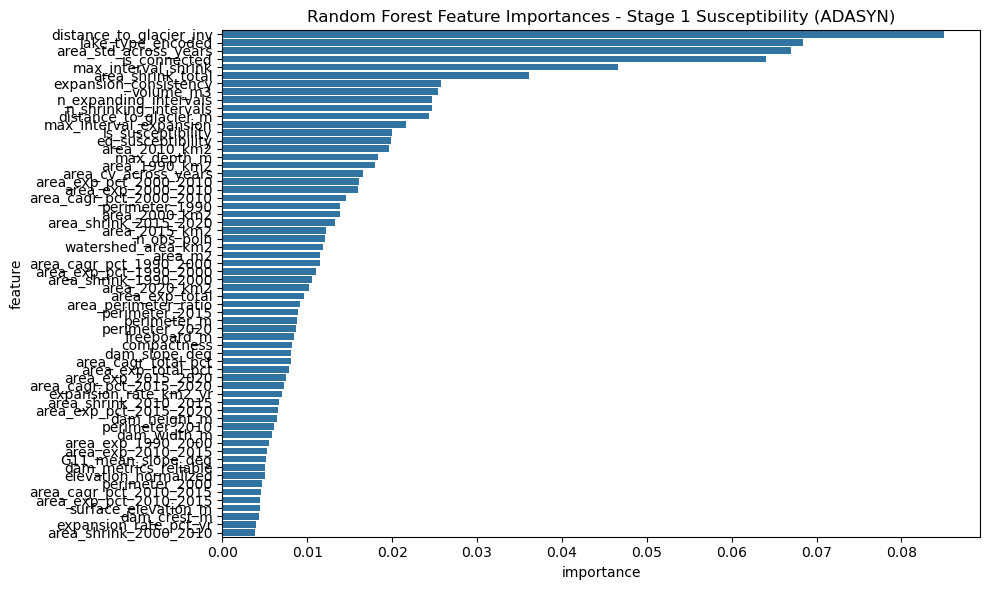


Done. RF + ADASYN outputs saved.


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from imblearn.over_sampling import ADASYN
except ImportError as e:
    raise ImportError(
        "ADASYN requires imbalanced-learn. Install with: pip install imbalanced-learn"
    ) from e

# -- 1. Load & prepare -------------------------------------------------------

# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")
lakes = lakes_clean.copy()  # Use the cleaned version from previous steps

# Encode lake_type to numeric (keep original column untouched)
le = LabelEncoder()
lakes['lake_type_encoded'] = le.fit_transform(lakes['lake_type'].astype(str))
print("Lake type mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Inverse distance feature: nearby lakes get higher value
lakes['distance_to_glacier_inv'] = 1.0 / (1.0 + lakes['distance_to_glacier_m'].clip(lower=0))

# Candidate features (no target leakage, no raw string IDs)
candidate_feature_cols = [
    'perimeter_2020', 'perimeter_1990',
       'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2',
       'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
       'expansion_rate_km2_yr', 'expansion_rate_pct_yr',
     'distance_to_glacier_m',
       'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility',
       'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2',
       'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000',
       'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
       'area_exp_2000_2010', 'area_exp_pct_2000_2010',
       'area_cagr_pct_2000_2010', 'area_exp_2010_2015',
       'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
       'area_exp_2015_2020', 'area_exp_pct_2015_2020',
       'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct',
       'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals',
       'area_shrink_1990_2000', 'area_shrink_2000_2010',
       'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total',
       'max_interval_expansion', 'max_interval_shrink', 'watershed_area_km2',
       'compactness', 'area_perimeter_ratio', 'elevation_normalized',
       'expansion_consistency', 'area_std_across_years',
       'area_cv_across_years', 'dam_crest_m', 'dam_height_m',
       'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m', 'freeboard_m',
       'n_obs_poin', 'geometry','lake_type_encoded','distance_to_glacier_inv'
]

available_feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
missing_feature_cols = [c for c in candidate_feature_cols if c not in lakes.columns]

if missing_feature_cols:
    print(f"Missing candidate features: {len(missing_feature_cols)}")
    print(missing_feature_cols)

# Ensure model matrix is numeric for ADASYN / RF
non_numeric_cols = [
    c for c in available_feature_cols
    if not pd.api.types.is_numeric_dtype(lakes[c])
]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")

feature_cols = [c for c in available_feature_cols if c not in non_numeric_cols]

if len(feature_cols) == 0:
    raise ValueError("No usable numeric feature columns available for modeling.")

# Keep only rows with complete model inputs and target
# Replace inf from ratio/cagr features before dropna
lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
model_df = lakes.dropna(subset=feature_cols + ['glof_happened']).copy()

if len(model_df) == 0:
    raise ValueError("No rows left after filtering for non-missing features and target.")

X = model_df[feature_cols].values
y = model_df['glof_happened'].astype(int).values

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
print(f"\nUsing {len(feature_cols)} features")
print(f"Class distribution -- GLOF: {n_pos}  No GLOF: {n_neg}")
if n_pos > 0:
    print(f"Imbalance ratio: 1:{max(1, n_neg // n_pos)}")
else:
    raise ValueError("No positive class rows found after filtering.")

# -- 2. Spatial cross-validation ---------------------------------------------

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = lat_bins * 5 + lon_bins

print(f"\nSpatial blocks: {spatial_blocks.nunique()} blocks")
print(spatial_blocks.value_counts().sort_index())

# Keep folds conservative for rare positives
n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

# Random Forest model
# With ADASYN, class_weight is set to None to avoid double-compensation.
model = RandomForestClassifier(
    n_estimators=10000,
    class_weight=None,
    max_features='sqrt',
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
)

# Store metrics across folds
fold_metrics = []
oof_probs = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=spatial_blocks)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Apply ADASYN only to training split (no leakage into validation)
    pos_train = int((y_train == 1).sum())
    if pos_train >= 6:
        n_neighbors = min(5, pos_train - 1)
        adasyn = ADASYN(random_state=42, n_neighbors=n_neighbors)
        X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)
    else:
        # Too few positives to run ADASYN safely
        X_train_res, y_train_res = X_train, y_train

    model.fit(X_train_res, y_train_res)

    val_probs = model.predict_proba(X_val)[:, 1]
    oof_probs[val_idx] = val_probs

    # For imbalanced data, keep AP as primary metric
    fold_ap = average_precision_score(y_val, val_probs)

    # ROC AUC can fail if a fold has a single class
    try:
        fold_auc = roc_auc_score(y_val, val_probs)
    except ValueError:
        fold_auc = np.nan

    # Temporary fold threshold by maximizing F2 (recall-focused)
    p, r, t = precision_recall_curve(y_val, val_probs)
    if len(t) > 0:
        f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1] + 1e-12)
        best_t = t[np.nanargmax(f2)]
    else:
        best_t = 0.5

    val_preds = (val_probs >= best_t).astype(int)
    report = classification_report(y_val, val_preds, output_dict=True, zero_division=0)

    fold_metrics.append({
        'fold': fold + 1,
        'roc_auc': fold_auc,
        'avg_precision': fold_ap,
        'threshold': float(best_t),
        'precision_glof': report.get('1', {}).get('precision', np.nan),
        'recall_glof': report.get('1', {}).get('recall', np.nan),
        'f1_glof': report.get('1', {}).get('f1-score', np.nan),
    })

    print(
        f"Fold {fold + 1} -- AUC: {fold_auc if not np.isnan(fold_auc) else float('nan'):.3f}  "
        f"AP: {fold_ap:.3f}  Recall(GLOF): {report.get('1', {}).get('recall', 0):.3f}"
    )

metrics_df = pd.DataFrame(fold_metrics)
print("\n-- CV Summary (RF + ADASYN) --")
print(metrics_df.drop('fold', axis=1).agg(['mean', 'std']).round(3))

valid_oof = ~np.isnan(oof_probs)
print(f"\nOverall OOF AP:   {average_precision_score(y[valid_oof], oof_probs[valid_oof]):.3f}")
try:
    print(f"Overall OOF AUC:  {roc_auc_score(y[valid_oof], oof_probs[valid_oof]):.3f}")
except ValueError:
    print("Overall OOF AUC:  NA (single-class issue in OOF subset)")

# Pick one global threshold from OOF by maximizing F2 (recall-priority)
p_all, r_all, t_all = precision_recall_curve(y[valid_oof], oof_probs[valid_oof])
if len(t_all) > 0:
    f2_all = (5 * p_all[:-1] * r_all[:-1]) / (4 * p_all[:-1] + r_all[:-1] + 1e-12)
    best_threshold = float(t_all[np.nanargmax(f2_all)])
else:
    best_threshold = 0.5
print(f"Chosen global decision threshold (F2-optimal): {best_threshold:.3f}")

# -- 3. Final model on all data ----------------------------------------------

# ADASYN on full training set for final model
if n_pos >= 6:
    adasyn_final = ADASYN(random_state=42, n_neighbors=min(5, n_pos - 1))
    X_final, y_final = adasyn_final.fit_resample(X, y)
else:
    X_final, y_final = X, y

model.fit(X_final, y_final)
model_df['glof_susceptibility_score'] = model.predict_proba(X)[:, 1]
model_df['glof_predicted_class'] = (model_df['glof_susceptibility_score'] >= best_threshold).astype(int)
model_df['glof_susceptibility_class'] = pd.cut(
    model_df['glof_susceptibility_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High']
)

# Write scores back to lakes
lakes['glof_susceptibility_score'] = np.nan
lakes['glof_predicted_class'] = pd.Series([pd.NA] * len(lakes), dtype='Int64')
lakes['glof_susceptibility_class'] = pd.Series([np.nan] * len(lakes), dtype='object')

lakes.loc[model_df.index, 'glof_susceptibility_score'] = model_df['glof_susceptibility_score'].values
lakes.loc[model_df.index, 'glof_predicted_class'] = model_df['glof_predicted_class'].astype('Int64').values
lakes.loc[model_df.index, 'glof_susceptibility_class'] = model_df['glof_susceptibility_class'].astype(str).values

# -- 4. Feature importance ----------------------------------------------------

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n-- Feature Importances (RF + ADASYN) --")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Random Forest Feature Importances - Stage 1 Susceptibility (ADASYN)')
plt.tight_layout()
plt.savefig(r"D:\Rubel\M.Tech\MTP\Phase 2\feature_importance_rf_adasyn.png", dpi=150)
plt.show()

# -- 5. Save outputs ----------------------------------------------------------

lakes.to_file(
    r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_susceptibility_rf_adasyn.gpkg",
    driver="GPKG"
)

metrics_df.to_csv(
    r"D:\Rubel\M.Tech\MTP\Phase 2\cv_metrics_rf_adasyn.csv",
    index=False
)

print("\nDone. RF + ADASYN outputs saved.")

# XGBoost

Dropping non-numeric features: ['wse_m_dam', 'geometry']
Class distribution -- GLOF: 42  No GLOF: 6880
Imbalance ratio: 1:163
Fold 1 -- AUC: 0.998  AP: 0.901  Recall(GLOF): 0.889
Fold 2 -- AUC: 0.971  AP: 0.934  Recall(GLOF): 0.933

XGB CV Summary (ADASYN)
      roc_auc  avg_precision  threshold  precision_glof  recall_glof  f1_glof
mean    0.984          0.917      0.379           0.887        0.911    0.897
std     0.019          0.024      0.453           0.160        0.031    0.098

Overall OOF AP:  0.927
Overall OOF AUC: 0.989
Chosen XGB threshold (F2-optimal): 0.059

XGB Feature Importances (ADASYN)
                feature  importance
             glof_count    0.726004
              contact_m    0.041399
  area_std_across_years    0.035237
         perimeter_1990    0.021197
    max_interval_shrink    0.011646
         perimeter_2000    0.009697
     watershed_area_km2    0.009598
              volume_m3    0.008716
area_cagr_pct_2000_2010    0.006355
            v_mean_2020    

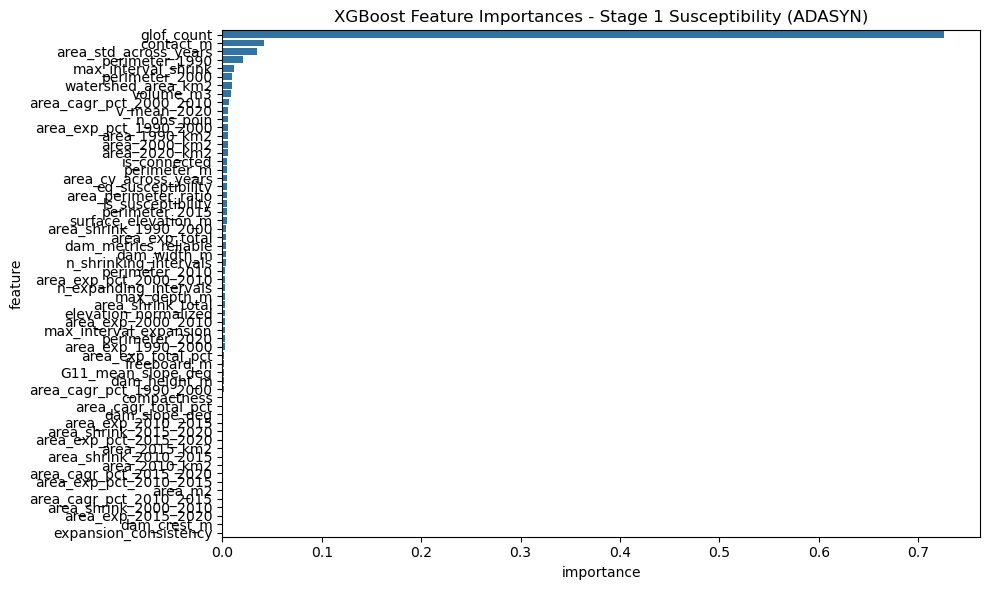


Done. XGBoost + ADASYN outputs saved.


In [386]:
# XGBoost model + ADASYN
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from imblearn.over_sampling import ADASYN
except ImportError as e:
    raise ImportError(
        "ADASYN requires imbalanced-learn. Install with: pip install imbalanced-learn"
    ) from e

# 1) Load
# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")
lakes = lakes_clean.copy()  # Use the cleaned version from previous steps

# 2) Feature prep
le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))

# Inverse distance feature (higher distance -> lower risk contribution)
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = [
   'perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010',
       'perimeter_2015', 'area_1990_km2', 'area_2000_km2', 'area_2010_km2',
       'area_2015_km2', 'area_2020_km2', 'glof_count', 'is_connected',
       'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility', 'volume_m3',
       'max_depth_m', 'surface_elevation_m', 'area_m2', 'perimeter_m',
       'G11_mean_slope_deg', 'area_exp_1990_2000', 'area_exp_pct_1990_2000',
       'area_cagr_pct_1990_2000', 'area_exp_2000_2010',
       'area_exp_pct_2000_2010', 'area_cagr_pct_2000_2010',
       'area_exp_2010_2015', 'area_exp_pct_2010_2015',
       'area_cagr_pct_2010_2015', 'area_exp_2015_2020',
       'area_exp_pct_2015_2020', 'area_cagr_pct_2015_2020', 'area_exp_total',
       'area_exp_total_pct', 'area_cagr_total_pct', 'n_expanding_intervals',
       'n_shrinking_intervals', 'area_shrink_1990_2000',
       'area_shrink_2000_2010', 'area_shrink_2010_2015',
       'area_shrink_2015_2020', 'area_shrink_total', 'max_interval_expansion',
       'max_interval_shrink', 'watershed_area_km2', 'compactness',
       'area_perimeter_ratio', 'elevation_normalized', 'expansion_consistency',
       'area_std_across_years', 'area_cv_across_years', 'dam_crest_m',
       'dam_height_m', 'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m',
       'freeboard_m', 'n_obs_poin', 'contact_m', 'v_mean_2020', 'geometry'
]

available_feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
missing_feature_cols = [c for c in candidate_feature_cols if c not in lakes.columns]
if missing_feature_cols:
    print(f"Missing candidate features: {len(missing_feature_cols)}")
    print(missing_feature_cols)

non_numeric_cols = [c for c in available_feature_cols if not pd.api.types.is_numeric_dtype(lakes[c])]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")

feature_cols = [c for c in available_feature_cols if c not in non_numeric_cols]
if len(feature_cols) == 0:
    raise ValueError("No usable numeric feature columns available for modeling.")

# Ensure model matrix is numeric for ADASYN / XGB
lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
if "glof_happened" not in lakes.columns:
    raise KeyError("Target column 'glof_happened' not found.")

model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
if len(model_df) == 0:
    raise ValueError("No rows left after filtering for non-missing features and target.")

X = model_df[feature_cols].values
y = model_df["glof_happened"].astype(int).values

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
print(f"Class distribution -- GLOF: {n_pos}  No GLOF: {n_neg}")
print(f"Imbalance ratio: 1:{max(1, n_neg // max(1, n_pos))}")

if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

# 3) Spatial groups
centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = lat_bins * 5 + lon_bins

n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

# 4) XGBoost model
# With ADASYN, keep scale_pos_weight neutral (1.0) to avoid double compensation.
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=4,
    subsample=0.7,
    colsample_bytree=0.9,
    reg_lambda=2.0,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=2,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

fold_metrics = []
oof_probs = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=spatial_blocks)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Apply ADASYN only to training data (no leakage)
    pos_train = int((y_train == 1).sum())
    # if pos_train >= 6:
    #     n_neighbors = min(5, pos_train - 1)
    #     adasyn = ADASYN(random_state=42, n_neighbors=n_neighbors)
    #     X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)
    # else:
    X_train_res, y_train_res = X_train, y_train

    xgb_model.fit(X_train_res, y_train_res)

    val_probs = xgb_model.predict_proba(X_val)[:, 1]
    oof_probs[val_idx] = val_probs

    fold_ap = average_precision_score(y_val, val_probs)
    try:
        fold_auc = roc_auc_score(y_val, val_probs)
    except ValueError:
        fold_auc = np.nan

    p, r, t = precision_recall_curve(y_val, val_probs)
    if len(t) > 0:
        f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1] + 1e-12)
        best_t = float(t[np.nanargmax(f2)])
    else:
        best_t = 0.5

    val_preds = (val_probs >= best_t).astype(int)
    report = classification_report(y_val, val_preds, output_dict=True, zero_division=0)

    fold_metrics.append({
        "fold": fold + 1,
        "roc_auc": fold_auc,
        "avg_precision": fold_ap,
        "threshold": best_t,
        "precision_glof": report.get("1", {}).get("precision", np.nan),
        "recall_glof": report.get("1", {}).get("recall", np.nan),
        "f1_glof": report.get("1", {}).get("f1-score", np.nan),
    })

    print(
        f"Fold {fold+1} -- AUC: {fold_auc if not np.isnan(fold_auc) else float('nan'):.3f}  "
        f"AP: {fold_ap:.3f}  Recall(GLOF): {report.get('1', {}).get('recall', 0):.3f}"
    )

metrics_df = pd.DataFrame(fold_metrics)
print("\nXGB CV Summary (ADASYN)")
print(metrics_df.drop("fold", axis=1).agg(["mean", "std"]).round(3))

valid_oof = ~np.isnan(oof_probs)
print(f"\nOverall OOF AP:  {average_precision_score(y[valid_oof], oof_probs[valid_oof]):.3f}")
try:
    print(f"Overall OOF AUC: {roc_auc_score(y[valid_oof], oof_probs[valid_oof]):.3f}")
except ValueError:
    print("Overall OOF AUC: NA")

# Global threshold from OOF by F2
p_all, r_all, t_all = precision_recall_curve(y[valid_oof], oof_probs[valid_oof])
if len(t_all) > 0:
    f2_all = (5 * p_all[:-1] * r_all[:-1]) / (4 * p_all[:-1] + r_all[:-1] + 1e-12)
    best_threshold = float(t_all[np.nanargmax(f2_all)])
else:
    best_threshold = 0.5
print(f"Chosen XGB threshold (F2-optimal): {best_threshold:.3f}")

# 5) Final fit on all data with ADASYN
if n_pos >= 6:
    adasyn_final = ADASYN(random_state=42, n_neighbors=min(5, n_pos - 1))
    X_final, y_final = adasyn_final.fit_resample(X, y)
else:
    X_final, y_final = X, y

xgb_model.fit(X_final, y_final)
model_df["xgb_glof_score"] = xgb_model.predict_proba(X)[:, 1]
model_df["xgb_glof_predicted_class"] = (model_df["xgb_glof_score"] >= best_threshold).astype(int)
model_df["xgb_glof_class"] = pd.cut(
    model_df["xgb_glof_score"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"]
)

# Write back to full lakes
lakes["xgb_glof_score"] = np.nan
lakes["xgb_glof_predicted_class"] = pd.Series([pd.NA] * len(lakes), dtype="Int64")
lakes["xgb_glof_class"] = pd.Series([np.nan] * len(lakes), dtype="object")

lakes.loc[model_df.index, "xgb_glof_score"] = model_df["xgb_glof_score"].values
lakes.loc[model_df.index, "xgb_glof_predicted_class"] = model_df["xgb_glof_predicted_class"].astype("Int64").values
lakes.loc[model_df.index, "xgb_glof_class"] = model_df["xgb_glof_class"].astype(str).values

# 6) Feature importance
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nXGB Feature Importances (ADASYN)")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("XGBoost Feature Importances - Stage 1 Susceptibility (ADASYN)")
plt.tight_layout()
plt.savefig(r"D:\Rubel\M.Tech\MTP\Phase 2\xgb_feature_importance_adasyn.png", dpi=150)
plt.show()

# 7) Save
lakes.to_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_susceptibility_xgb_adasyn.gpkg", driver="GPKG")
metrics_df.to_csv(r"D:\Rubel\M.Tech\MTP\Phase 2\xgb_cv_metrics_adasyn.csv", index=False)

print("\nDone. XGBoost + ADASYN outputs saved.")

In [107]:
lakes_clean['dam_slope_deg'].describe()

count    6922.000000
mean        5.986197
std         6.380166
min         0.000000
25%         1.132386
50%         3.777251
75%         8.699836
max        47.460675
Name: dam_slope_deg, dtype: float64

In [407]:
# XGBoost tuning for high-recall GLOF detection (spatial CV)
import geopandas as gpd
import pandas as pd
import numpy as np
from itertools import product
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import os

# Load data
# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")

# Feature prep
le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = [
    'perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010',
       'perimeter_2015', 'area_1990_km2', 'area_2000_km2', 'area_2010_km2',
       'area_2015_km2', 'area_2020_km2', 'is_connected',
       'eq_susceptibility', 'ls_susceptibility', 'volume_m3',
       'max_depth_m', 'surface_elevation_m', 'area_m2', 'perimeter_m',
       'G11_mean_slope_deg', 'area_exp_1990_2000', 'area_exp_pct_1990_2000',
       'area_cagr_pct_1990_2000', 'area_exp_2000_2010',
       'area_exp_pct_2000_2010', 'area_cagr_pct_2000_2010',
       'area_exp_2010_2015', 'area_exp_pct_2010_2015',
       'area_cagr_pct_2010_2015', 'area_exp_2015_2020',
       'area_exp_pct_2015_2020', 'area_cagr_pct_2015_2020', 'area_exp_total',
       'area_exp_total_pct', 'area_cagr_total_pct', 'n_expanding_intervals',
       'n_shrinking_intervals', 'area_shrink_1990_2000',
       'area_shrink_2000_2010', 'area_shrink_2010_2015',
       'area_shrink_2015_2020', 'area_shrink_total', 'max_interval_expansion',
       'max_interval_shrink', 'watershed_area_km2', 'compactness',
       'area_perimeter_ratio', 'elevation_normalized', 'expansion_consistency',
       'area_std_across_years', 'area_cv_across_years', 'dam_crest_m',
       'dam_height_m', 'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m',
       'freeboard_m', 'n_obs_poin', 'contact_m', 'v_mean_2020', 'lake_type_encoded', 'distance_to_glacier_inv'
]

available_feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
non_numeric_cols = [c for c in available_feature_cols if not pd.api.types.is_numeric_dtype(lakes[c])]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")
feature_cols = [c for c in available_feature_cols if c not in non_numeric_cols]

if "glof_happened" not in lakes.columns:
    raise KeyError("Column 'glof_happened' not found in lakes_clean.gpkg")

# Clean invalid values before filtering
lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
X = model_df[feature_cols].values
y = model_df["glof_happened"].astype(int).values

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

# Spatial groups (same logic as current model)
centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = lat_bins * 5 + lon_bins

n_splits = 5 if n_pos >= 50 else 3
cv = StratifiedGroupKFold(n_splits=n_splits)

# Compact grid (recall-oriented, still practical runtime)
param_grid = {
    "n_estimators": [800, 1200, 2000],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 4, 5],
    "min_child_weight": [1, 2, 4],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "reg_lambda": [1.0, 2.0],
    'scale_pos_weight': [1, 2, 5, 10]  # Include some weight tuning for imbalance,
}

combos = list(product(
    param_grid["n_estimators"],
    param_grid["learning_rate"],
    param_grid["max_depth"],
    param_grid["min_child_weight"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
    param_grid["reg_lambda"],
    param_grid["scale_pos_weight"],
))

# To limit runtime, evaluate first N combinations
max_trials = 100
combos = combos[:max_trials]

results = []

for trial_id, (n_est, lr, md, mcw, ss, cs, rl, spw) in enumerate(combos, start=1):
    fold_ap = []
    fold_recall = []
    fold_precision = []

    for train_idx, val_idx in cv.split(X, y, groups=spatial_blocks):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = XGBClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=md,
            min_child_weight=mcw,
            subsample=ss,
            colsample_bytree=cs,
            reg_lambda=rl,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=spw,
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
        )

        model.fit(X_train, y_train)
        probs = model.predict_proba(X_val)[:, 1]

        # Recall-focused threshold (maximize F2 on this fold)
        p, r, t = precision_recall_curve(y_val, probs)
        if len(t) > 0:
            f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1] + 1e-12)
            best_idx = int(np.nanargmax(f2))
            best_p = float(p[:-1][best_idx])
            best_r = float(r[:-1][best_idx])
        else:
            best_p, best_r = 0.0, 0.0

        fold_ap.append(float(average_precision_score(y_val, probs)))
        fold_precision.append(best_p)
        fold_recall.append(best_r)

    results.append({
        "trial": trial_id,
        "n_estimators": n_est,
        "learning_rate": lr,
        "max_depth": md,
        "min_child_weight": mcw,
        "subsample": ss,
        "colsample_bytree": cs,
        "reg_lambda": rl,
        'scale_pos_weight': spw,
        "mean_ap": float(np.mean(fold_ap)),
        "mean_precision": float(np.mean(fold_precision)),
        "mean_recall": float(np.mean(fold_recall)),
    })

results_df = pd.DataFrame(results)

# Rank by recall first, then AP, then precision
results_df = results_df.sort_values(
    by=["mean_recall", "mean_ap", "mean_precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Top 10 tuning results:")
print(results_df.head(10).to_string(index=False))

best_params = results_df.iloc[0]
print("\nBest params (recall-priority):")

# Save OOF probabilities for top-10 trials

out_dir = "xgb_results"
os.makedirs(out_dir, exist_ok=True)

top10_trials = results_df.head(10).copy().reset_index(drop=True)
top10_trials.to_csv(os.path.join(out_dir, "top10_trials_summary.csv"), index=False)

# Combined OOF table (one column per trial)
oof_all_df = pd.DataFrame({
    "row_id": model_df.index.to_numpy(),
    "y_true": y
})

for rank, row in top10_trials.iterrows():
    n_est = int(row["n_estimators"])
    lr = float(row["learning_rate"])
    md = int(row["max_depth"])
    mcw = float(row["min_child_weight"])
    ss = float(row["subsample"])
    cs = float(row["colsample_bytree"])
    rl = float(row["reg_lambda"])
    spw = float(row["scale_pos_weight"])
    trial_num = int(row["trial"])
    trial_name = f"trial_{trial_num:04d}"

    oof_probs = np.full(len(y), np.nan, dtype=np.float32)

    for train_idx, val_idx in cv.split(X, y, groups=spatial_blocks):
        model = XGBClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=md,
            min_child_weight=mcw,
            subsample=ss,
            colsample_bytree=cs,
            reg_lambda=rl,
            scale_pos_weight=spw,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
        )
        model.fit(X[train_idx], y[train_idx])
        oof_probs[val_idx] = model.predict_proba(X[val_idx])[:, 1]

    # Save individual trial OOF file
    pd.DataFrame({
        "row_id": model_df.index.to_numpy(),
        "y_true": y,
        "oof_prob": oof_probs
    }).to_csv(os.path.join(out_dir, f"{trial_name}_oof_probs.csv"), index=False)

    # Add to combined file
    oof_all_df[trial_name] = oof_probs

# Save combined OOF file for best 10 trials
oof_all_df.to_csv(os.path.join(out_dir, "best10_trials_oof_probs.csv"), index=False)
print(f"Saved top-10 OOF probability files in: {out_dir}")
print(best_params[[
    "n_estimators", "learning_rate", "max_depth", "min_child_weight",
    "subsample", "colsample_bytree", "reg_lambda", "mean_recall", "mean_ap", "mean_precision"
]])

# Save tuning table
results_df.to_csv(r"D:\Rubel\M.Tech\MTP\Phase 2\xgb_tuning_results.csv", index=False)
print("\nSaved tuning results to xgb_tuning_results.csv")

Top 10 tuning results:
 trial  n_estimators  learning_rate  max_depth  min_child_weight  subsample  colsample_bytree  reg_lambda  scale_pos_weight  mean_ap  mean_precision  mean_recall
    61           800           0.03          3                 2        0.9               0.9         2.0                 1 0.177943        0.188753     0.337973
    53           800           0.03          3                 2        0.9               0.8         2.0                 1 0.173789        0.161888     0.337973
     5           800           0.03          3                 1        0.8               0.8         2.0                 1 0.189299        0.213463     0.336386
    99           800           0.03          4                 1        0.8               0.8         1.0                 5 0.162993        0.127161     0.332723
     1           800           0.03          3                 1        0.8               0.8         1.0                 1 0.215796        0.292949     0.314164
    2

# pytorch

In [393]:
# PyTorch baseline for rare-event learning: Class-Weighted BCE vs Focal Loss
import os
import copy
import numpy as np
import pandas as pd
import geopandas as gpd
import torch
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ------------------------- 0) Reproducibility -------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------- 1) Data prep -------------------------
# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")
lakes = lakes_clean.copy()

le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

feature_cols = [
   'perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010',
       'perimeter_2015', 'area_1990_km2', 'area_2000_km2', 'area_2010_km2',
       'area_2015_km2', 'area_2020_km2', 'is_connected',
       'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility', 'volume_m3',
       'max_depth_m', 'surface_elevation_m', 'area_m2', 'perimeter_m',
       'G11_mean_slope_deg', 'area_exp_1990_2000', 'area_exp_pct_1990_2000',
       'area_cagr_pct_1990_2000', 'area_exp_2000_2010',
       'area_exp_pct_2000_2010', 'area_cagr_pct_2000_2010',
       'area_exp_2010_2015', 'area_exp_pct_2010_2015',
       'area_cagr_pct_2010_2015', 'area_exp_2015_2020',
       'area_exp_pct_2015_2020', 'area_cagr_pct_2015_2020', 'area_exp_total',
       'area_exp_total_pct', 'area_cagr_total_pct', 'n_expanding_intervals',
       'n_shrinking_intervals', 'area_shrink_1990_2000',
       'area_shrink_2000_2010', 'area_shrink_2010_2015',
       'area_shrink_2015_2020', 'area_shrink_total', 'max_interval_expansion',
       'max_interval_shrink', 'watershed_area_km2', 'compactness',
       'area_perimeter_ratio', 'elevation_normalized', 'expansion_consistency',
       'area_std_across_years', 'area_cv_across_years', 'dam_crest_m',
       'dam_height_m', 'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m',
       'freeboard_m', 'n_obs_poin', 'contact_m', 'v_mean_2020']

feature_cols = [c for c in feature_cols if c in lakes.columns]
non_numeric_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(lakes[c])]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")
feature_cols = [c for c in feature_cols if c not in non_numeric_cols]

model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
X = model_df[feature_cols].to_numpy(dtype=np.float32)
y = model_df["glof_happened"].astype(int).to_numpy(dtype=np.int64)

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = (lat_bins * 5 + lon_bins).to_numpy()

print(f"Class distribution -- GLOF: {n_pos}  No GLOF: {n_neg}")
print(f"Imbalance ratio (neg:pos): {n_neg}:{n_pos} = {n_neg / max(1, n_pos):.2f}")

# ------------------------- 2) Model + losses -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class MLP(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.25),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.20),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.20),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.10),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.10),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="sum"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * ((1 - p_t) ** self.gamma) * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

# Choose one: "weighted_bce" or "focal"
LOSS_MODE = "weighted_bce"

# For weighted BCE: set positive-class penalty based on imbalance
pos_weight_value = float(n_neg / max(1, n_pos)) * 10

# Focal parameters: alpha should be higher when positives are rare
focal_alpha = min(0.95, max(0.25, pos_weight_value / (1.0 + pos_weight_value)))
focal_gamma = 1.0

# ------------------------- 3) Training settings -------------------------
n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

epochs = 500
batch_size = 128
lr = 1e-4
weight_decay = 1e-4
patience = 30
min_delta = 1e-4

fold_rows = []
oof_probs = np.full(len(y), np.nan, dtype=float)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=spatial_blocks), start=1):
    X_train_raw, X_val_raw = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler = QuantileTransformer(
        n_quantiles=min(1000, max(20, len(train_idx))),
        output_distribution="uniform",
        random_state=SEED,
    )
    X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_val = scaler.transform(X_val_raw).astype(np.float32)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    model = MLP(in_features=X.shape[1]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-6
    )

    if LOSS_MODE == "weighted_bce":
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
        )
    else:
        criterion = FocalLossWithLogits(alpha=focal_alpha, gamma=focal_gamma)

    best_fold_ap = -1.0
    best_state = None
    bad_epochs = 0
    early_stopped = False

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_probs_epoch = torch.sigmoid(val_logits).cpu().numpy()

        val_ap = average_precision_score(y_val, val_probs_epoch)
        scheduler.step(val_ap)

        if val_ap > best_fold_ap + min_delta:
            best_fold_ap = val_ap
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                early_stopped = True
                print(f"Fold {fold}: early stopping at epoch {epoch + 1} | best_val_ap={best_fold_ap:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_probs = torch.sigmoid(val_logits).cpu().numpy()

    oof_probs[val_idx] = val_probs

    fold_ap = average_precision_score(y_val, val_probs)
    try:
        fold_auc = roc_auc_score(y_val, val_probs)
    except ValueError:
        fold_auc = np.nan

    p, r, t = precision_recall_curve(y_val, val_probs)
    if len(t) > 0:
        f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1] + 1e-12)
        best_t = float(t[np.nanargmax(f2)])
    else:
        best_t = 0.5

    fold_rows.append({
        "fold": fold,
        "auc": fold_auc,
        "ap": float(fold_ap),
        "best_t_f2": best_t,
        "best_val_ap_earlystop": float(best_fold_ap),
        "early_stopped": early_stopped,
    })

    print(f"Fold {fold} | AUC: {fold_auc if not np.isnan(fold_auc) else float('nan'):.3f} | AP: {fold_ap:.3f}")

# ------------------------- 4) OOF summary -------------------------
cv_df = pd.DataFrame(fold_rows)
print("\nCV summary:")
print(cv_df.drop(columns=["fold"]).agg(["mean", "std"]).round(4))

valid = ~np.isnan(oof_probs)
oof_ap = average_precision_score(y[valid], oof_probs[valid])
try:
    oof_auc = roc_auc_score(y[valid], oof_probs[valid])
except ValueError:
    oof_auc = np.nan

p_all, r_all, t_all = precision_recall_curve(y[valid], oof_probs[valid])
if len(t_all) > 0:
    f2_all = (5 * p_all[:-1] * r_all[:-1]) / (4 * p_all[:-1] + r_all[:-1] + 1e-12)
    best_threshold = float(t_all[np.nanargmax(f2_all)])
else:
    best_threshold = 0.5

print(f"\nLOSS_MODE: {LOSS_MODE}")
print(f"OOF AP: {oof_ap:.4f}")
print(f"OOF AUC: {oof_auc if not np.isnan(oof_auc) else float('nan'):.4f}")
print(f"F2-optimal threshold: {best_threshold:.4f}")
print(f"Early-stopped folds: {int(cv_df['early_stopped'].sum())}/{len(cv_df)}")

# Save metrics and OOF probabilities
out_dir = r"D:\Rubel\M.Tech\MTP\Phase 2"
metrics_name = f"torch_{LOSS_MODE}_cv_metrics.csv"
oof_name = f"torch_{LOSS_MODE}_oof_probs.csv"
metrics_path = os.path.join(out_dir, metrics_name)
oof_path = os.path.join(out_dir, oof_name)

cv_df.to_csv(metrics_path, index=False)
pd.DataFrame({"y_true": y, "oof_prob": oof_probs}).to_csv(oof_path, index=False)

print(f"Saved metrics: {metrics_path}")
print(f"Saved OOF probs: {oof_path}")

Dropping non-numeric features: ['wse_m_dam']
Class distribution -- GLOF: 42  No GLOF: 6880
Imbalance ratio (neg:pos): 6880:42 = 163.81
Using device: cuda
Fold 1: early stopping at epoch 76 | best_val_ap=0.0262
Fold 1 | AUC: 0.739 | AP: 0.026
Fold 2: early stopping at epoch 61 | best_val_ap=0.2656
Fold 2 | AUC: 0.804 | AP: 0.266

CV summary:
         auc      ap  best_t_f2  best_val_ap_earlystop  early_stopped
mean  0.7716  0.1459     0.9574                 0.1459            1.0
std   0.0454  0.1693     0.0521                 0.1693            0.0

LOSS_MODE: weighted_bce
OOF AP: 0.0554
OOF AUC: 0.7465
F2-optimal threshold: 0.9909
Early-stopped folds: 2/2
Saved metrics: D:\Rubel\M.Tech\MTP\Phase 2\torch_weighted_bce_cv_metrics.csv
Saved OOF probs: D:\Rubel\M.Tech\MTP\Phase 2\torch_weighted_bce_oof_probs.csv


In [394]:
import numpy as np
import pandas as pd
oof_probs = pd.read_csv(r'torch_weighted_bce_oof_probs.csv')
probs = oof_probs["oof_prob"]

print("Probability distribution:")
print(f"  > 0.99  : {(probs > 0.99).sum()} lakes")
print(f"  0.5–0.99: {((probs > 0.5) & (probs <= 0.99)).sum()} lakes")
print(f"  0.1–0.5 : {((probs > 0.1) & (probs <= 0.5)).sum()} lakes")
print(f"  < 0.1   : {(probs < 0.1).sum()} lakes")

Probability distribution:
  > 0.99  : 136 lakes
  0.5–0.99: 3364 lakes
  0.1–0.5 : 3178 lakes
  < 0.1   : 244 lakes


In [395]:
y_true = oof_probs["y_true"].values
probs  = oof_probs["oof_prob"].values

# Where are the actual GLOF lakes in the distribution?
glof_probs     = probs[y_true == 1]
non_glof_probs = probs[y_true == 0]

print(f"── Actual GLOF lakes (n=42) probability distribution ──")
print(f"  > 0.99  : {(glof_probs > 0.99).sum()}")
print(f"  0.5–0.99: {((glof_probs > 0.5) & (glof_probs <= 0.99)).sum()}")
print(f"  0.1–0.5 : {((glof_probs > 0.1) & (glof_probs <= 0.5)).sum()}")
print(f"  < 0.1   : {(glof_probs < 0.1).sum()}")
print(f"\nMedian prob for GLOF lakes:     {np.median(glof_probs):.4f}")
print(f"Median prob for non-GLOF lakes: {np.median(non_glof_probs):.4f}")

# Recall at different operating thresholds
print(f"\n── Recall at different thresholds ──")
for thresh in [0.9, 0.7, 0.5, 0.3, 0.1]:
    preds    = (probs >= thresh).astype(int)
    tp       = ((preds == 1) & (y_true == 1)).sum()
    fp       = ((preds == 1) & (y_true == 0)).sum()
    recall   = tp / 42
    flagged  = tp + fp
    print(f"  Threshold {thresh:.1f} → "
          f"Recall: {recall:.2f} ({tp}/42 GLOF caught)  "
          f"Flagged: {flagged} lakes  "
          f"Precision: {tp/flagged:.3f}" if flagged > 0 else "  No lakes flagged")

# Top-N analysis — operationally most meaningful
print(f"\n── GLOF lakes captured in top-N ranked ──")
ranked_idx = np.argsort(probs)[::-1]
for n in [50, 100, 200, 350, 500,1000,2000,5000]:
    hits = y_true[ranked_idx[:n]].sum()
    print(f"  Top {n:4d} lakes → {hits}/42 GLOF captured "
          f"({hits/42*100:.0f}% recall)")

── Actual GLOF lakes (n=42) probability distribution ──
  > 0.99  : 10
  0.5–0.99: 24
  0.1–0.5 : 8
  < 0.1   : 0

Median prob for GLOF lakes:     0.9016
Median prob for non-GLOF lakes: 0.5041

── Recall at different thresholds ──
  Threshold 0.9 → Recall: 0.52 (22/42 GLOF caught)  Flagged: 1011 lakes  Precision: 0.022
  Threshold 0.7 → Recall: 0.67 (28/42 GLOF caught)  Flagged: 2256 lakes  Precision: 0.012
  Threshold 0.5 → Recall: 0.81 (34/42 GLOF caught)  Flagged: 3500 lakes  Precision: 0.010
  Threshold 0.3 → Recall: 0.98 (41/42 GLOF caught)  Flagged: 5155 lakes  Precision: 0.008
  Threshold 0.1 → Recall: 1.00 (42/42 GLOF caught)  Flagged: 6678 lakes  Precision: 0.006

── GLOF lakes captured in top-N ranked ──
  Top   50 lakes → 5/42 GLOF captured (12% recall)
  Top  100 lakes → 8/42 GLOF captured (19% recall)
  Top  200 lakes → 10/42 GLOF captured (24% recall)
  Top  350 lakes → 11/42 GLOF captured (26% recall)
  Top  500 lakes → 13/42 GLOF captured (31% recall)
  Top 1000 lakes →

In [411]:
# Improved PyTorch rare-event model (new cell): balanced sampler + hybrid loss + early stopping
import os
import copy
import random
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, QuantileTransformer
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# ------------------------- 0) Reproducibility -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------- 1) Data prep -------------------------
# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")
lakes = lakes_clean.copy()
le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = [
  "perimeter_2020", "perimeter_1990", "perimeter_2000", "perimeter_2010", "perimeter_2015",
    "area_1990_km2", "area_2000_km2", "area_2010_km2", "area_2015_km2", "area_2020_km2",
    "is_connected", "wse_m_dam", "eq_susceptibility", "ls_susceptibility", "volume_m3",
    "max_depth_m", "surface_elevation_m", "area_m2", "perimeter_m", "G11_mean_slope_deg",
    "area_exp_1990_2000", "area_exp_pct_1990_2000", "area_cagr_pct_1990_2000",
    "area_exp_2000_2010", "area_exp_pct_2000_2010", "area_cagr_pct_2000_2010",
    "area_exp_2010_2015", "area_exp_pct_2010_2015", "area_cagr_pct_2010_2015",
    "area_exp_2015_2020", "area_exp_pct_2015_2020", "area_cagr_pct_2015_2020",
    "area_exp_total", "area_exp_total_pct", "area_cagr_total_pct", "n_expanding_intervals",
    "n_shrinking_intervals", "area_shrink_1990_2000", "area_shrink_2000_2010",
    "area_shrink_2010_2015", "area_shrink_2015_2020", "area_shrink_total",
    "max_interval_expansion", "max_interval_shrink", "watershed_area_km2", "compactness",
    "area_perimeter_ratio", "elevation_normalized", "expansion_consistency",
    "area_std_across_years", "area_cv_across_years", "dam_crest_m", "dam_height_m",
    "dam_metrics_reliable", "dam_slope_deg", "dam_width_m", "freeboard_m",
    "n_obs_poin", "lake_type_encoded", "distance_to_glacier_inv",'contact_m', 'v_mean_2020'
]

available_feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
missing_feature_cols = [c for c in candidate_feature_cols if c not in lakes.columns]
if missing_feature_cols:
    print(f"Missing candidate features: {len(missing_feature_cols)}")
    print(missing_feature_cols)

non_numeric_cols = [
    c for c in available_feature_cols
    if not pd.api.types.is_numeric_dtype(lakes[c])
]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")

feature_cols = [c for c in available_feature_cols if c not in non_numeric_cols]
if len(feature_cols) == 0:
    raise ValueError("No usable numeric feature columns available for modeling.")

if "glof_happened" not in lakes.columns:
    raise KeyError("Column 'glof_happened' not found in data.")

# Remove inf artifacts from ratio/cagr features before filtering rows
lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
if len(model_df) == 0:
    raise ValueError("No rows left after filtering for non-missing features and target.")

X_df = model_df[feature_cols].copy()
y = model_df["glof_happened"].astype(int).to_numpy(dtype=np.int64)

# Light log transforms for heavy-tailed variables
for c in [
    "perimeter_m", "area_m2", "volume_m3",'perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010', 'perimeter_2015',
    'area_1990_km2', 'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2'
]:
    if c in X_df.columns:
        X_df[c] = np.log1p(np.clip(X_df[c].to_numpy(dtype=np.float64), a_min=0, a_max=None))

X = X_df.to_numpy(dtype=np.float32)
n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = (lat_bins * 5 + lon_bins).to_numpy()

print(f"Using {len(feature_cols)} features")
print(f"Class distribution -- GLOF: {n_pos} | No GLOF: {n_neg}")
print(f"Imbalance ratio (neg:pos): {n_neg}:{n_pos} = {n_neg / max(1, n_pos):.2f}")

# ------------------------- 2) Model and losses -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class ResidualMLP(nn.Module):
    def __init__(self, in_features: int, hidden: int = 256, dropout: float = 0.20):
        super().__init__()
        self.inp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.block1 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.block4 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.block5 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )

        self.out = nn.Linear(hidden, 1)

    def forward(self, x):
        h =  self.inp(x)
        h =  h + self.block1(h)
        h =  h + self.block2(h)
        h =  h + self.block3(h)
        h =  h + self.block4(h)
        # h =  h + self.block5(h)
        return self.out(h).squeeze(1)

class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="sum")
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * ((1 - p_t) ** self.gamma) * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

# Hybrid objective: weighted BCE + focal
pos_weight_value = float(n_neg / max(1, n_pos)) * 5 # amplify imbalance penalty for BCE
focal_alpha = 0.5 # moderate alpha for focal to focus on positives without ignoring negatives
bce_weight = 0.6
focal_weight = 0.4

# ------------------------- 3) CV + training -------------------------
n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

max_epochs = 300
batch_size = 128
lr = 1e-4
weight_decay = 5e-4
patience = 35

fold_rows = []
oof_probs = np.full(len(y), np.nan, dtype=float)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=spatial_blocks), start=1):
    X_train_raw, X_val_raw = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler = QuantileTransformer(
        n_quantiles=min(1000, max(20, len(train_idx))),
        output_distribution="uniform",
        random_state=SEED,
    )
    X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_val = scaler.transform(X_val_raw).astype(np.float32)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

    # Balanced mini-batches via weighted sampling
    class_counts = np.bincount(y_train)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        sampler=sampler,
        drop_last=False,
    )

    model = ResidualMLP(in_features=X.shape[1], hidden=512, dropout=0.20).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=10, min_lr=1e-5
    )

    bce_criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    )
    focal_criterion = FocalLossWithLogits(alpha=focal_alpha, gamma=2.0)

    best_ap = -1.0
    best_state = None
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss_bce = bce_criterion(logits, yb)
            loss_focal = focal_criterion(logits, yb)
            loss = bce_weight * loss_bce + focal_weight * loss_focal
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_probs = torch.sigmoid(val_logits).cpu().numpy()

        val_ap = average_precision_score(y_val, val_probs)
        scheduler.step(val_ap)

        if val_ap > best_ap + 1e-5:
            best_ap = val_ap
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Fold {fold}: early stopping at epoch {epoch + 1} | best_val_ap={best_ap:.4f}")
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_probs = torch.sigmoid(val_logits).cpu().numpy()

    oof_probs[val_idx] = val_probs

    fold_ap = average_precision_score(y_val, val_probs)
    try:
        fold_auc = roc_auc_score(y_val, val_probs)
    except ValueError:
        fold_auc = np.nan

    p, r, t = precision_recall_curve(y_val, val_probs)
    if len(t) > 0:
        f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1] + 1e-12)
        best_t = float(t[np.nanargmax(f2)])
    else:
        best_t = 0.5

    fold_rows.append({
        "fold": fold,
        "auc": fold_auc,
        "ap": float(fold_ap),
        "best_t_f2": best_t,
        "best_val_ap_earlystop": float(best_ap),
    })

    print(f"Fold {fold} | AP: {fold_ap:.4f} | AUC: {fold_auc if not np.isnan(fold_auc) else float('nan'):.4f} | BestValAP: {best_ap:.4f}")

# ------------------------- 4) OOF summary and save -------------------------
cv_df = pd.DataFrame(fold_rows)
print("\nImproved CV summary:")
print(cv_df.drop(columns=["fold"]).agg(["mean", "std"]).round(4))

valid = ~np.isnan(oof_probs)
oof_ap = average_precision_score(y[valid], oof_probs[valid])
try:
    oof_auc = roc_auc_score(y[valid], oof_probs[valid])
except ValueError:
    oof_auc = np.nan

p_all, r_all, t_all = precision_recall_curve(y[valid], oof_probs[valid])
if len(t_all) > 0:
    f2_all = (5 * p_all[:-1] * r_all[:-1]) / (4 * p_all[:-1] + r_all[:-1] + 1e-12)
    best_threshold = float(t_all[np.nanargmax(f2_all)])
else:
    best_threshold = 0.5

print(f"\nImproved OOF AP: {oof_ap:.4f}")
print(f"Improved OOF AUC: {oof_auc if not np.isnan(oof_auc) else float('nan'):.4f}")
print(f"Improved F2-optimal threshold: {best_threshold:.4f}")

out_dir = r"D:\Rubel\M.Tech\MTP\Phase 2"
cv_out = os.path.join(out_dir, "torch_improved_cv_metrics.csv")
oof_out = os.path.join(out_dir, "torch_improved_oof_probs.csv")
cv_df.to_csv(cv_out, index=False)
pd.DataFrame({"y_true": y, "oof_prob": oof_probs}).to_csv(oof_out, index=False)
print(f"Saved: {cv_out}")
print(f"Saved: {oof_out}")

Dropping non-numeric features: ['wse_m_dam']
Using 61 features
Class distribution -- GLOF: 42 | No GLOF: 6880
Imbalance ratio (neg:pos): 6880:42 = 163.81
Using device: cuda
Fold 1: early stopping at epoch 82 | best_val_ap=0.0621
Fold 1 | AP: 0.0621 | AUC: 0.7868 | BestValAP: 0.0621
Fold 2: early stopping at epoch 69 | best_val_ap=0.1989
Fold 2 | AP: 0.1989 | AUC: 0.8303 | BestValAP: 0.1989

Improved CV summary:
         auc      ap  best_t_f2  best_val_ap_earlystop
mean  0.8085  0.1305     0.3855                 0.1305
std   0.0308  0.0967     0.2777                 0.0967

Improved OOF AP: 0.0758
Improved OOF AUC: 0.7898
Improved F2-optimal threshold: 0.1891
Saved: D:\Rubel\M.Tech\MTP\Phase 2\torch_improved_cv_metrics.csv
Saved: D:\Rubel\M.Tech\MTP\Phase 2\torch_improved_oof_probs.csv


In [412]:
import numpy as np
import pandas as pd
oof_probs = pd.read_csv(r'torch_improved_oof_probs.csv')
probs = oof_probs["oof_prob"]

print("Probability distribution:")
print(f"  > 0.99  : {(probs > 0.99).sum()} lakes")
print(f"  0.5–0.99: {((probs > 0.5) & (probs <= 0.99)).sum()} lakes")
print(f"  0.1–0.5 : {((probs > 0.1) & (probs <= 0.5)).sum()} lakes")
print(f"  < 0.1   : {(probs < 0.1).sum()} lakes")

Probability distribution:
  > 0.99  : 23 lakes
  0.5–0.99: 21 lakes
  0.1–0.5 : 18 lakes
  < 0.1   : 6860 lakes


In [413]:
y_true = oof_probs["y_true"].values
probs  = oof_probs["oof_prob"].values

# Where are the actual GLOF lakes in the distribution?
glof_probs     = probs[y_true == 1]
non_glof_probs = probs[y_true == 0]

print(f"── Actual GLOF lakes (n=42) probability distribution ──")
print(f"  > 0.99  : {(glof_probs > 0.99).sum()}")
print(f"  0.5–0.99: {((glof_probs > 0.5) & (glof_probs <= 0.99)).sum()}")
print(f"  0.1–0.5 : {((glof_probs > 0.1) & (glof_probs <= 0.5)).sum()}")
print(f"  < 0.1   : {(glof_probs < 0.1).sum()}")
print(f"\nMedian prob for GLOF lakes:     {np.median(glof_probs):.4f}")
print(f"Median prob for non-GLOF lakes: {np.median(non_glof_probs):.4f}")

# Recall at different operating thresholds
print(f"\n── Recall at different thresholds ──")
for thresh in [0.9, 0.7, 0.5, 0.3, 0.1]:
    preds    = (probs >= thresh).astype(int)
    tp       = ((preds == 1) & (y_true == 1)).sum()
    fp       = ((preds == 1) & (y_true == 0)).sum()
    recall   = tp / 42
    flagged  = tp + fp
    print(f"  Threshold {thresh:.1f} → "
          f"Recall: {recall:.2f} ({tp}/42 GLOF caught)  "
          f"Flagged: {flagged} lakes  "
          f"Precision: {tp/flagged:.3f}" if flagged > 0 else "  No lakes flagged")

# Top-N analysis — operationally most meaningful
print(f"\n── GLOF lakes captured in top-N ranked ──")
ranked_idx = np.argsort(probs)[::-1]
for n in [50, 100, 200, 350, 500,1000,2000,5000]:
    hits = y_true[ranked_idx[:n]].sum()
    print(f"  Top {n:4d} lakes → {hits}/42 GLOF captured "
          f"({hits/42*100:.0f}% recall)")

── Actual GLOF lakes (n=42) probability distribution ──
  > 0.99  : 4
  0.5–0.99: 5
  0.1–0.5 : 1
  < 0.1   : 32

Median prob for GLOF lakes:     0.0000
Median prob for non-GLOF lakes: 0.0000

── Recall at different thresholds ──
  Threshold 0.9 → Recall: 0.12 (5/42 GLOF caught)  Flagged: 29 lakes  Precision: 0.172
  Threshold 0.7 → Recall: 0.14 (6/42 GLOF caught)  Flagged: 33 lakes  Precision: 0.182
  Threshold 0.5 → Recall: 0.21 (9/42 GLOF caught)  Flagged: 44 lakes  Precision: 0.205
  Threshold 0.3 → Recall: 0.21 (9/42 GLOF caught)  Flagged: 52 lakes  Precision: 0.173
  Threshold 0.1 → Recall: 0.24 (10/42 GLOF caught)  Flagged: 62 lakes  Precision: 0.161

── GLOF lakes captured in top-N ranked ──
  Top   50 lakes → 9/42 GLOF captured (21% recall)
  Top  100 lakes → 10/42 GLOF captured (24% recall)
  Top  200 lakes → 13/42 GLOF captured (31% recall)
  Top  350 lakes → 16/42 GLOF captured (38% recall)
  Top  500 lakes → 19/42 GLOF captured (45% recall)
  Top 1000 lakes → 22/42 GLOF ca

# Hyperparameter search


#

In [123]:
# Hyperparameter search cell for PyTorch rare-event model
# Tries architecture/loss/preprocessing combinations and saves trial results + best OOF

import os
import copy
import random
import numpy as np
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from itertools import product
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    QuantileTransformer,
    PowerTransformer,
    LabelEncoder,
)
from sklearn.metrics import average_precision_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# ------------------------- 0) Reproducibility -------------------------
SEED = 14
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------- 1) Data prep -------------------------
# lakes = gpd.read_file(r"D:\Rubel\M.Tech\MTP\Phase 2\lakes_clean.gpkg")
lakes = lakes_clean.copy()

le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = ['perimeter_2020', 'perimeter_1990',
       'perimeter_2000', 'perimeter_2010', 'perimeter_2015', 'area_1990_km2',
       'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
       'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility',
       'volume_m3', 'max_depth_m', 'surface_elevation_m', 'area_m2',
       'perimeter_m', 'G11_mean_slope_deg', 'area_exp_1990_2000',
       'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
       'area_exp_2000_2010', 'area_exp_pct_2000_2010',
       'area_cagr_pct_2000_2010', 'area_exp_2010_2015',
       'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
       'area_exp_2015_2020', 'area_exp_pct_2015_2020',
       'area_cagr_pct_2015_2020', 'area_exp_total', 'area_exp_total_pct',
       'area_cagr_total_pct', 'n_expanding_intervals', 'n_shrinking_intervals',
       'area_shrink_1990_2000', 'area_shrink_2000_2010',
       'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total',
       'max_interval_expansion', 'max_interval_shrink', 'watershed_area_km2',
       'compactness', 'area_perimeter_ratio', 'elevation_normalized',
       'expansion_consistency', 'area_std_across_years',
       'area_cv_across_years', 'dam_crest_m', 'dam_height_m',
       'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m', 'freeboard_m',
       'n_obs_poin','lake_type_encoded','distance_to_glacier_inv'
]

feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
if "glof_happened" not in lakes.columns:
    raise KeyError("Column 'glof_happened' not found in lakes_clean.gpkg")

model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
X_df_full = model_df[feature_cols].copy()
y = model_df["glof_happened"].astype(int).to_numpy(dtype=np.int64)

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = (lat_bins * 5 + lon_bins).to_numpy()

print(f"Using {len(feature_cols)} features")
print(f"Class distribution -- GLOF: {n_pos} | No GLOF: {n_neg}")
print(f"Imbalance ratio (neg:pos): {n_neg}:{n_pos} = {n_neg / max(1, n_pos):.2f}")

# ------------------------- 2) Config space -------------------------
# Requested tuning knobs
hidden_sizes = [256, 384, 512,128]
dropouts = [0.4, 0.2, 0.3]
activations = ["relu", "leakyrelu"]
focal_alphas = [0.25, 0.5, 0.75]
focal_gammas = [1.0, 2.0, 3.0]
pos_weight_amplifiers = [2, 5, 10, 20]
loss_weight_pairs = [
    (0.8, 0.2),
    (0.5, 0.5),
    (0.2, 0.8),
]
preprocess_methods = [

    "quantile_uniform",
]

all_combos = list(product(
    hidden_sizes,
    dropouts,
    activations,
    focal_alphas,
    focal_gammas,
    pos_weight_amplifiers,
    loss_weight_pairs,
    preprocess_methods,
))

# Keep runtime practical by sampling a subset of full grid
MAX_TRIALS = 200
if len(all_combos) > MAX_TRIALS:
    sampled_combos = random.sample(all_combos, MAX_TRIALS)
else:
    sampled_combos = all_combos

print(f"Total possible combos: {len(all_combos)}")
print(f"Running sampled trials: {len(sampled_combos)}")

# ------------------------- 3) Model/loss helpers -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def get_activation(name: str):
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.1)
    raise ValueError(f"Unknown activation: {name}")


class ConfigMLP(nn.Module):
    def __init__(self, in_features: int, hidden: int, dropout: float, activation: str):
        super().__init__()
        h2 = max(16, hidden // 2)
        h3 = max(8, hidden // 4)
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            get_activation(activation),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, h2),
            get_activation(activation),
            nn.LayerNorm(h2),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            get_activation(activation),
            nn.LayerNorm(h3),
            nn.Dropout(dropout),
            nn.Linear(h3, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * ((1 - p_t) ** self.gamma) * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def make_preprocessor(name: str, n_train: int):
    if name == "standard" or name == "standard_log1p":
        return StandardScaler()
    if name == "robust":
        return RobustScaler()
    if name == "quantile_normal":
        return QuantileTransformer(
            n_quantiles=min(1000, max(20, n_train)),
            output_distribution="normal",
            random_state=SEED,
        )
    if name == "quantile_uniform":
        return QuantileTransformer(
            n_quantiles=min(1000, max(20, n_train)),
            output_distribution="uniform",
            random_state=SEED,
        )
    if name == "power_yeo":
        return PowerTransformer(method="yeo-johnson", standardize=True)
    raise ValueError(f"Unknown preprocessing method: {name}")


# ------------------------- 4) Search loop -------------------------
n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

max_epochs = 500
batch_size = 128
lr = 2e-3
weight_decay = 1e-3
l1_lambda = 1e-6
patience = 25
min_delta = 1e-4
min_epochs = 20

log1p_candidates = [
    c for c in [
        "perimeter_m",
        "area_m2",
        "volume_m3",
        "max_depth_m",
        "Elevation",
        "surface_elevation_m",
        
    ] if c in feature_cols
]

trial_rows = []
best = {
    "ap": -1.0,
    "oof": None,
    "cfg": None,
}

for trial_i, combo in enumerate(tqdm(sampled_combos, desc="Hyperparameter trials", unit="trial"), start=1):
    (
        hidden,
        dropout,
        activation,
        alpha,
        gamma,
        pos_amp,
        loss_pair,
        preprocess_name,
    ) = combo
    bce_weight, focal_weight = loss_pair

    oof_probs = np.full(len(y), np.nan, dtype=float)
    fold_aps = []
    fold_aucs = []

    try:
        for fold, (train_idx, val_idx) in enumerate(cv.split(X_df_full.values, y, groups=spatial_blocks), start=1):
            X_train_df = X_df_full.iloc[train_idx].copy()
            X_val_df = X_df_full.iloc[val_idx].copy()
            y_train, y_val = y[train_idx], y[val_idx]

            # Optional log1p before scaling for heavy-tailed vars
            if preprocess_name == "standard_log1p":
                for c in log1p_candidates:
                    X_train_df[c] = np.log1p(np.clip(X_train_df[c].to_numpy(dtype=np.float64), a_min=0, a_max=None))
                    X_val_df[c] = np.log1p(np.clip(X_val_df[c].to_numpy(dtype=np.float64), a_min=0, a_max=None))

            prep = make_preprocessor(preprocess_name, len(train_idx))
            X_train = prep.fit_transform(X_train_df.values).astype(np.float32)
            X_val = prep.transform(X_val_df.values).astype(np.float32)

            X_train_t = torch.tensor(X_train, dtype=torch.float32)
            y_train_t = torch.tensor(y_train, dtype=torch.float32)
            X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

            class_counts = np.bincount(y_train)
            class_weights = 1.0 / np.maximum(class_counts, 1)
            sample_weights = class_weights[y_train]
            sampler = WeightedRandomSampler(
                weights=torch.tensor(sample_weights, dtype=torch.double),
                num_samples=len(sample_weights),
                replacement=True,
            )

            train_loader = DataLoader(
                TensorDataset(X_train_t, y_train_t),
                batch_size=batch_size,
                sampler=sampler,
                drop_last=False,
            )

            model = ConfigMLP(
                in_features=X_train.shape[1],
                hidden=hidden,
                dropout=dropout,
                activation=activation,
            ).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-5
            )

            pos_weight_value = float((n_neg / max(1, n_pos)) * pos_amp)
            bce_criterion = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
            )
            focal_criterion = FocalLossWithLogits(alpha=alpha, gamma=gamma)

            best_fold_ap = -1.0
            best_state = None
            bad_epochs = 0

            for epoch in range(max_epochs):
                model.train()
                for xb, yb in train_loader:
                    xb = xb.to(device)
                    yb = yb.to(device)

                    optimizer.zero_grad()
                    logits = model(xb)
                    loss_bce = bce_criterion(logits, yb)
                    loss_focal = focal_criterion(logits, yb)
                    loss = bce_weight * loss_bce + focal_weight * loss_focal
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                    optimizer.step()

                model.eval()
                with torch.no_grad():
                    val_logits = model(X_val_t)
                    val_probs = torch.sigmoid(val_logits).cpu().numpy()

                val_ap = average_precision_score(y_val, val_probs)
                scheduler.step(val_ap)

                if val_ap > best_fold_ap + min_delta:
                    best_fold_ap = val_ap
                    best_state = copy.deepcopy(model.state_dict())
                    bad_epochs = 0
                else:
                    bad_epochs += 1
                    if bad_epochs >= patience:
                        break

            model.load_state_dict(best_state)
            model.eval()
            with torch.no_grad():
                val_logits = model(X_val_t)
                val_probs = torch.sigmoid(val_logits).cpu().numpy()

            oof_probs[val_idx] = val_probs
            fold_ap = average_precision_score(y_val, val_probs)
            try:
                fold_auc = roc_auc_score(y_val, val_probs)
            except ValueError:
                fold_auc = np.nan

            fold_aps.append(float(fold_ap))
            fold_aucs.append(float(fold_auc) if not np.isnan(fold_auc) else np.nan)

        valid = ~np.isnan(oof_probs)
        oof_ap = float(average_precision_score(y[valid], oof_probs[valid]))
        try:
            oof_auc = float(roc_auc_score(y[valid], oof_probs[valid]))
        except ValueError:
            oof_auc = float("nan")

        row = {
            "trial": trial_i,
            "hidden": hidden,
            "dropout": dropout,
            "activation": activation,
            "focal_alpha": alpha,
            "focal_gamma": gamma,
            "pos_weight_amp": pos_amp,
            "bce_weight": bce_weight,
            "focal_weight": focal_weight,
            "preprocess": preprocess_name,
            "mean_fold_ap": float(np.nanmean(fold_aps)),
            "mean_fold_auc": float(np.nanmean(fold_aucs)),
            "oof_ap": oof_ap,
            "oof_auc": oof_auc,
        }
        trial_rows.append(row)

        if oof_ap > best["ap"]:
            best["ap"] = oof_ap
            best["oof"] = oof_probs.copy()
            best["cfg"] = row.copy()

    except Exception as e:
        trial_rows.append({
            "trial": trial_i,
            "hidden": hidden,
            "dropout": dropout,
            "activation": activation,
            "focal_alpha": alpha,
            "focal_gamma": gamma,
            "pos_weight_amp": pos_amp,
            "bce_weight": bce_weight,
            "focal_weight": focal_weight,
            "preprocess": preprocess_name,
            "mean_fold_ap": np.nan,
            "mean_fold_auc": np.nan,
            "oof_ap": np.nan,
            "oof_auc": np.nan,
            "error": str(e),
        })

# ------------------------- 5) Save outputs -------------------------
results_df = pd.DataFrame(trial_rows)
results_df = results_df.sort_values("oof_ap", ascending=False, na_position="last").reset_index(drop=True)

out_dir = r"D:\Rubel\M.Tech\MTP\Phase 2"
results_path = os.path.join(out_dir, "torch_hparam_search_results.csv")
best_oof_path = os.path.join(out_dir, "torch_best_hparam_oof_probs.csv")
best_cfg_path = os.path.join(out_dir, "torch_best_hparam_config.csv")

results_df.to_csv(results_path, index=False)

if best["oof"] is not None:
    pd.DataFrame({"y_true": y, "oof_prob": best["oof"]}).to_csv(best_oof_path, index=False)
    pd.DataFrame([best["cfg"]]).to_csv(best_cfg_path, index=False)

print("\nTop 10 trials by OOF AP:")
print(results_df.head(10).to_string(index=False))
print(f"\nSaved search table: {results_path}")
if best["oof"] is not None:
    print(f"Saved best OOF probs: {best_oof_path}")
    print(f"Saved best config: {best_cfg_path}")

Using 60 features
Class distribution -- GLOF: 42 | No GLOF: 6880
Imbalance ratio (neg:pos): 6880:42 = 163.81
Total possible combos: 2592
Running sampled trials: 200
Using device: cuda


Hyperparameter trials:   0%|          | 0/200 [00:00<?, ?trial/s]


Top 10 trials by OOF AP:
 trial  hidden  dropout activation  focal_alpha  focal_gamma  pos_weight_amp  bce_weight  focal_weight       preprocess  mean_fold_ap  mean_fold_auc   oof_ap  oof_auc
   171     384      0.2       relu         0.25          1.0               2         0.2           0.8 quantile_uniform      0.137067       0.806895 0.132506 0.800363
   116     256      0.2  leakyrelu         0.50          3.0              10         0.8           0.2 quantile_uniform      0.129195       0.807228 0.103967 0.798367
   162     512      0.3  leakyrelu         0.75          2.0               2         0.8           0.2 quantile_uniform      0.108165       0.774093 0.094108 0.732126
   125     384      0.3       relu         0.75          1.0               5         0.2           0.8 quantile_uniform      0.118196       0.713959 0.094083 0.716584
   142     384      0.3  leakyrelu         0.25          1.0               5         0.2           0.8 quantile_uniform      0.131972      

In [ ]:
# Recall-first model selection (target recall >= 0.80 and precision >= 0.10) and save best model
import os
import json
import joblib
import numpy as np
import pandas as pd
from itertools import product
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import recall_score, precision_score, average_precision_score, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

TARGET_RECALL = 0.80
MIN_PRECISION = 0.10
SEED = 10

# ------------------------- 1) Data prep -------------------------
lakes = lakes_clean.copy()

le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = [
    'perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010', 'perimeter_2015',
    'area_1990_km2', 'area_2000_km2', 'area_2010_km2', 'area_2015_km2', 'area_2020_km2',
    'is_connected', 'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility', 'volume_m3',
    'max_depth_m', 'surface_elevation_m', 'area_m2', 'perimeter_m', 'G11_mean_slope_deg',
    'area_exp_1990_2000', 'area_exp_pct_1990_2000', 'area_cagr_pct_1990_2000',
    'area_exp_2000_2010', 'area_exp_pct_2000_2010', 'area_cagr_pct_2000_2010',
    'area_exp_2010_2015', 'area_exp_pct_2010_2015', 'area_cagr_pct_2010_2015',
    'area_exp_2015_2020', 'area_exp_pct_2015_2020', 'area_cagr_pct_2015_2020',
    'area_exp_total', 'area_exp_total_pct', 'area_cagr_total_pct', 'n_expanding_intervals',
    'n_shrinking_intervals', 'area_shrink_1990_2000', 'area_shrink_2000_2010',
    'area_shrink_2010_2015', 'area_shrink_2015_2020', 'area_shrink_total',
    'max_interval_expansion', 'max_interval_shrink', 'watershed_area_km2', 'compactness',
    'area_perimeter_ratio', 'elevation_normalized', 'expansion_consistency',
    'area_std_across_years', 'area_cv_across_years', 'dam_crest_m', 'dam_height_m',
    'dam_metrics_reliable', 'dam_slope_deg', 'dam_width_m', 'freeboard_m',
    'n_obs_poin', 'lake_type_encoded', 'distance_to_glacier_inv'
]

available_feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
non_numeric_cols = [c for c in available_feature_cols if not pd.api.types.is_numeric_dtype(lakes[c])]
feature_cols = [c for c in available_feature_cols if c not in non_numeric_cols]

if len(feature_cols) == 0:
    raise ValueError("No usable numeric feature columns available.")
if "glof_happened" not in lakes.columns:
    raise KeyError("Target column 'glof_happened' not found.")

lakes[feature_cols] = lakes[feature_cols].replace([np.inf, -np.inf], np.nan)
model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
if len(model_df) == 0:
    raise ValueError("No rows left after filtering for non-missing features and target.")

X = model_df[feature_cols].to_numpy(dtype=np.float32)
y = model_df["glof_happened"].astype(int).to_numpy()

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = (lat_bins * 5 + lon_bins).to_numpy()

n_splits = 5 if n_pos >= 50 else 3
cv = StratifiedGroupKFold(n_splits=n_splits)

print(f"Rows used: {len(model_df)} | Positives: {n_pos} | Negatives: {n_neg}")
print(f"Using {len(feature_cols)} numeric features")
print(f"Target recall: {TARGET_RECALL:.2f} | Minimum precision: {MIN_PRECISION:.2f}")

# ------------------------- 2) Fast recall-oriented search -------------------------
# Keep grid compact for speed
param_grid = {
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.05],
    "min_child_weight": [1, 2],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "reg_lambda": [1.0, 2.0],
    "scale_pos_weight": [5.0, 10.0, float(n_neg / max(1, n_pos))],
}

combos = list(product(
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["min_child_weight"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
    param_grid["reg_lambda"],
    param_grid["scale_pos_weight"],
))

results = []
best_feasible = None
best_fallback = None

for i, (md, lr, mcw, ss, cs, rl, spw) in enumerate(combos, start=1):
    oof_probs = np.full(len(y), np.nan, dtype=float)

    for train_idx, val_idx in cv.split(X, y, groups=spatial_blocks):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = XGBClassifier(
            n_estimators=1500,
            learning_rate=lr,
            max_depth=md,
            min_child_weight=mcw,
            subsample=ss,
            colsample_bytree=cs,
            reg_lambda=rl,
            scale_pos_weight=spw,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
            early_stopping_rounds=80,
        )

        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        oof_probs[val_idx] = model.predict_proba(X_val)[:, 1]

    valid = ~np.isnan(oof_probs)
    p, r, t = precision_recall_curve(y[valid], oof_probs[valid])

    # Threshold policy:
    # 1) prefer thresholds meeting both recall and precision constraints,
    # 2) else thresholds meeting recall with highest precision,
    # 3) else maximize recall.
    if len(t) > 0:
        p_use = p[:-1]
        r_use = r[:-1]

        both_mask = (r_use >= TARGET_RECALL) & (p_use >= MIN_PRECISION)
        recall_mask = r_use >= TARGET_RECALL

        if np.any(both_mask):
            idx_local = np.where(both_mask)[0][np.argmax(p_use[both_mask])]
        elif np.any(recall_mask):
            idx_local = np.where(recall_mask)[0][np.argmax(p_use[recall_mask])]
        else:
            idx_local = int(np.nanargmax(r_use))

        best_t = float(t[idx_local])
    else:
        best_t = 0.5

    y_pred = (oof_probs[valid] >= best_t).astype(int)
    rec = float(recall_score(y[valid], y_pred, zero_division=0))
    prec = float(precision_score(y[valid], y_pred, zero_division=0))
    ap = float(average_precision_score(y[valid], oof_probs[valid]))
    feasible = bool((rec >= TARGET_RECALL) and (prec >= MIN_PRECISION))

    row = {
        "trial": i,
        "max_depth": md,
        "learning_rate": lr,
        "min_child_weight": mcw,
        "subsample": ss,
        "colsample_bytree": cs,
        "reg_lambda": rl,
        "scale_pos_weight": float(spw),
        "threshold": best_t,
        "recall": rec,
        "precision": prec,
        "avg_precision": ap,
        "feasible": feasible,
    }
    results.append(row)

    if feasible:
        if (best_feasible is None) or ((rec, prec, ap) > (best_feasible["recall"], best_feasible["precision"], best_feasible["avg_precision"])):
            best_feasible = row

    if (best_fallback is None) or ((rec, prec, ap) > (best_fallback["recall"], best_fallback["precision"], best_fallback["avg_precision"])):
        best_fallback = row

best = best_feasible if best_feasible is not None else best_fallback
results_df = pd.DataFrame(results).sort_values(
    by=["feasible", "recall", "precision", "avg_precision"], ascending=[False, False, False, False]
).reset_index(drop=True)

print("Top recall-first results:")
print(results_df.head(10).to_string(index=False))
print("\nBest config:")
print(pd.Series(best).to_string())

if best_feasible is None:
    print(
        f"\nWarning: no trial met BOTH recall >= {TARGET_RECALL:.2f} and precision >= {MIN_PRECISION:.2f}. "
        f"Best fallback has recall={best['recall']:.3f}, precision={best['precision']:.3f}."
    )
else:
    print(
        f"\nSuccess: constraints met with recall={best['recall']:.3f} and precision={best['precision']:.3f}."
    )

# ------------------------- 3) Fit best model on full data -------------------------
best_model = XGBClassifier(
    n_estimators=900,
    learning_rate=float(best["learning_rate"]),
    max_depth=int(best["max_depth"]),
    min_child_weight=float(best["min_child_weight"]),
    subsample=float(best["subsample"]),
    colsample_bytree=float(best["colsample_bytree"]),
    reg_lambda=float(best["reg_lambda"]),
    scale_pos_weight=float(best["scale_pos_weight"]),
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)
best_model.fit(X, y)

# ------------------------- 4) Save model + metadata -------------------------
out_dir = r"D:\Rubel\M.Tech\MTP\Phase 2"
os.makedirs(out_dir, exist_ok=True)

model_bundle_path = os.path.join(out_dir, "best_recall_xgb_model.joblib")
results_path = os.path.join(out_dir, "best_recall_xgb_trials.csv")
meta_path = os.path.join(out_dir, "best_recall_xgb_meta.json")

oof_probs_best = np.full(len(y), np.nan, dtype=float)
# Optional: store OOF from best trial by rerunning once for reproducibility of saved outputs
for train_idx, val_idx in cv.split(X, y, groups=spatial_blocks):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    m = XGBClassifier(
        n_estimators=1500,
        learning_rate=float(best["learning_rate"]),
        max_depth=int(best["max_depth"]),
        min_child_weight=float(best["min_child_weight"]),
        subsample=float(best["subsample"]),
        colsample_bytree=float(best["colsample_bytree"]),
        reg_lambda=float(best["reg_lambda"]),
        scale_pos_weight=float(best["scale_pos_weight"]),
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
        early_stopping_rounds=80,
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_probs_best[val_idx] = m.predict_proba(X_val)[:, 1]

oof_path = os.path.join(out_dir, "best_recall_xgb_oof_probs.csv")
pd.DataFrame({"y_true": y, "oof_prob": oof_probs_best}).to_csv(oof_path, index=False)

# TP/FP/FN counts for best model at selected threshold (on OOF predictions)
best_pred = (oof_probs_best >= float(best["threshold"])).astype(int)
tp = int(((best_pred == 1) & (y == 1)).sum())
fp = int(((best_pred == 1) & (y == 0)).sum())
fn = int(((best_pred == 0) & (y == 1)).sum())

joblib.dump({
    "model": best_model,
    "feature_cols": feature_cols,
    "threshold": float(best["threshold"]),
    "target_recall": float(TARGET_RECALL),
    "min_precision": float(MIN_PRECISION),
    "label_encoder_classes": list(le.classes_),
    "tp": tp,
    "fp": fp,
    "fn": fn,
}, model_bundle_path)

results_df.to_csv(results_path, index=False)
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump({
        "best": {k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else bool(v) if isinstance(v, (np.bool_, bool)) else v) for k, v in best.items()},
        "target_recall": TARGET_RECALL,
        "min_precision": MIN_PRECISION,
        "constraints_met": bool(best.get("feasible", False)),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "n_rows": int(len(model_df)),
        "n_pos": int(n_pos),
        "n_neg": int(n_neg),
        "n_features": int(len(feature_cols)),
        "feature_cols": feature_cols,
        "model_bundle_path": model_bundle_path,
        "results_path": results_path,
        "oof_path": oof_path,
    }, f, indent=2)

print(f"\nBest model counts at threshold {float(best['threshold']):.4f} -> TP: {tp}, FP: {fp}, FN: {fn}")
print(f"Saved model bundle: {model_bundle_path}")
print(f"Saved trial table: {results_path}")
print(f"Saved OOF probabilities: {oof_path}")
print(f"Saved metadata: {meta_path}")

Rows used: 6922 | Positives: 42 | Negatives: 6880
Using 59 numeric features
Target recall: 0.80 | Minimum precision: 0.10
Top recall-first results:
 trial  max_depth  learning_rate  min_child_weight  subsample  colsample_bytree  reg_lambda  scale_pos_weight  threshold   recall  precision  avg_precision  feasible
    37          4           0.05                 1        0.8               0.8         1.0          5.000000   0.002991 0.880952   0.015507       0.094283     False
    41          4           0.05                 1        0.8               0.8         2.0         10.000000   0.002452 0.880952   0.012513       0.100329     False
    11          3           0.03                 2        0.8               0.8         2.0         10.000000   0.002905 0.857143   0.013905       0.088339     False
    39          4           0.05                 1        0.8               0.8         1.0        163.809524   0.000941 0.857143   0.011568       0.045622     False
     8          3     

In [357]:
 # Diagnostic check for low-probability GLOF lakes vs high-probability GLOF lakes
import numpy as np
import pandas as pd

# Use the OOF CSV created by the best hyperparameter run if available
diag_oof = pd.read_csv(r"torch results\trial_0091_oof_probs.csv")

# Try to align with the current model_df used in the training/search cell
if "model_df" not in globals():
    raise NameError("model_df is not available. Re-run the training/search cell first.")

if len(diag_oof) != len(model_df):
    raise ValueError(
        f"OOF rows ({len(diag_oof)}) do not match model_df rows ({len(model_df)}). "
        "Re-run the search cell and the save cell using the same filtered data."
    )

# Standardize columns
if "y_true" not in diag_oof.columns or "oof_prob" not in diag_oof.columns:
    raise KeyError("Expected columns y_true and oof_prob in the OOF CSV.")

check_df = model_df.reset_index(drop=True).copy()
check_df["y_true"] = diag_oof["y_true"].astype(int).to_numpy()
check_df["oof_prob"] = diag_oof["oof_prob"].astype(float).to_numpy()
check_df["rank"] = check_df["oof_prob"].rank(method="average", ascending=False)
if "glake_id" not in check_df.columns and "GLAKE_ID" in check_df.columns:
    check_df["glake_id"] = check_df["GLAKE_ID"]

# Core distribution checks
pos_df = check_df[check_df["y_true"] == 1].copy()
neg_df = check_df[check_df["y_true"] == 0].copy()
low_pos_df = pos_df[pos_df["oof_prob"] < 0.1].copy()
high_pos_df = pos_df[pos_df["oof_prob"] >= 0.99].copy()
mid_pos_df = pos_df[(pos_df["oof_prob"] >= 0.1) & (pos_df["oof_prob"] < 0.99)].copy()

print("=== OOF Probability Audit ===")
print(f"Total rows: {len(check_df)}")
print(f"Positives: {len(pos_df)} | Negatives: {len(neg_df)}")
print(f"High-prob positives (>= 0.99): {len(high_pos_df)}")
print(f"Mid-prob positives (0.1 to 0.99): {len(mid_pos_df)}")
print(f"Low-prob positives (< 0.1): {len(low_pos_df)}")
print()

# Sanity checks for class separation
print("=== Separation checks ===")
print(f"Median OOF prob for positives: {pos_df['oof_prob'].median():.4f}")
print(f"Median OOF prob for negatives: {neg_df['oof_prob'].median():.4f}")
print(f"Mean OOF prob for positives:   {pos_df['oof_prob'].mean():.4f}")
print(f"Mean OOF prob for negatives:   {neg_df['oof_prob'].mean():.4f}")
print()

# Threshold behavior
print("=== Threshold behavior ===")
for thresh in [0.9, 0.7, 0.5, 0.3, 0.1, 0.05]:
    preds = (check_df["oof_prob"].to_numpy() >= thresh).astype(int)
    y_true = check_df["y_true"].to_numpy()
    tp = int(((preds == 1) & (y_true == 1)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())
    recall = tp / max(1, len(pos_df))
    precision = tp / max(1, tp + fp)
    print(f"Threshold {thresh:>4.2f} -> TP={tp:2d}, FP={fp:4d}, FN={fn:2d}, Recall={recall:.3f}, Precision={precision:.3f}")
print()

# Top-N capture
print("=== Top-N capture ===")
ranked_idx = np.argsort(check_df["oof_prob"].to_numpy())[::-1]
for n in [25, 50, 100, 200, 350, 500, 1000, 2000, 5000]:
    n = min(n, len(check_df))
    hits = int(check_df.iloc[ranked_idx[:n]]["y_true"].sum())
    print(f"Top {n:4d} -> {hits}/{len(pos_df)} positives captured ({hits / max(1, len(pos_df)):.3f} recall)")
print()

# Show the missed GLOF lakes
print("=== Lowest-probability positives ===")
show_cols = [c for c in ["glake_id", "oof_prob", "rank"] if c in low_pos_df.columns]
missed_cols = show_cols + [c for c in ["glof_happened", "lake_type", "lake_type_encoded", "watershed_area_km2", "G11_mean_slope_deg", "distance_to_glacier_m", "distance_to_glacier_inv", "expansion_rate_km2_yr", "expansion_rate_pct_yr", "area_m2", "volume_m3", "max_depth_m", "surface_elevation_m"] if c in low_pos_df.columns]
print(low_pos_df.sort_values("oof_prob", ascending=True)[missed_cols].head(20).to_string(index=False))
print()

# Compare feature means: high-prob positives vs low-prob positives
compare_features = [c for c in [
    "area_m2",
    "volume_m3",
    "max_depth_m",
    "surface_elevation_m",
    "distance_to_glacier_m",
    "distance_to_glacier_inv",
    "expansion_rate_km2_yr",
    "expansion_rate_pct_yr",
    "watershed_area_km2",
    "G11_mean_slope_deg",
] if c in check_df.columns]

if compare_features:
    summary = pd.DataFrame({
        "high_prob_pos_mean": high_pos_df[compare_features].mean(numeric_only=True),
        "low_prob_pos_mean": low_pos_df[compare_features].mean(numeric_only=True),
        "all_neg_mean": neg_df[compare_features].mean(numeric_only=True),
    })
    summary["high_vs_low_diff"] = summary["high_prob_pos_mean"] - summary["low_prob_pos_mean"]
    print("=== Feature means: high-prob positives vs low-prob positives vs negatives ===")
    print(summary.round(4).to_string())
    print()
else:
    print("No comparable numeric features found for mean comparison.")

# Spatial pattern check if centroid/geometry available
if "geometry" in check_df.columns:
    try:
        cent = check_df.geometry.centroid.to_crs("EPSG:4326")
        check_df["centroid_lat"] = cent.y
        check_df["centroid_lon"] = cent.x
        if len(low_pos_df) > 0:
            print("=== Spatial ranges for low-prob positives ===")
            print(f"Latitude range:  {low_pos_df['centroid_lat'].min():.4f} to {low_pos_df['centroid_lat'].max():.4f}")
            print(f"Longitude range: {low_pos_df['centroid_lon'].min():.4f} to {low_pos_df['centroid_lon'].max():.4f}")
    except Exception as e:
        print(f"Could not compute centroid-based spatial check: {e}")

# Quick interpretation guide
print()
print("=== Interpretation guide ===")
print("If low-prob positives have very different feature means from high-prob positives, you likely have multiple GLOF subtypes.")
print("If they cluster spatially, the spatial split may be making generalization harder.")
print("If they look similar to negatives, the current features are probably missing the signal.")

=== OOF Probability Audit ===
Total rows: 6922
Positives: 42 | Negatives: 6880
High-prob positives (>= 0.99): 24
Mid-prob positives (0.1 to 0.99): 13
Low-prob positives (< 0.1): 5

=== Separation checks ===
Median OOF prob for positives: 0.9926
Median OOF prob for negatives: 0.0142
Mean OOF prob for positives:   0.8173
Mean OOF prob for negatives:   0.3059

=== Threshold behavior ===
Threshold 0.90 -> TP=30, FP=1589, FN=12, Recall=0.714, Precision=0.019
Threshold 0.70 -> TP=34, FP=1886, FN= 8, Recall=0.810, Precision=0.018
Threshold 0.50 -> TP=35, FP=2085, FN= 7, Recall=0.833, Precision=0.017
Threshold 0.30 -> TP=36, FP=2288, FN= 6, Recall=0.857, Precision=0.015
Threshold 0.10 -> TP=37, FP=2661, FN= 5, Recall=0.881, Precision=0.014
Threshold 0.05 -> TP=37, FP=2880, FN= 5, Recall=0.881, Precision=0.013

=== Top-N capture ===
Top   25 -> 3/42 positives captured (0.071 recall)
Top   50 -> 5/42 positives captured (0.119 recall)
Top  100 -> 7/42 positives captured (0.167 recall)
Top  200 ->

In [127]:
# Check these two specifically
suspicious = ['GL078487E33018', 'GL278280N918068E']
print(lakes[lakes['GLAKE_ID'].isin(suspicious)][
    ['GLAKE_ID', 'lake_type', 'distance_to_glacier_m', 
     'expansion_rate_km2_yr', 'is_connected', 'watershed_area_km2',
     'eq_susceptibility', 'ls_susceptibility']
])

              GLAKE_ID lake_type  distance_to_glacier_m  \
6915  GL278280N918068E      M(o)           14281.335716   

      expansion_rate_km2_yr  is_connected  watershed_area_km2  \
6915               0.000008             0               0.044   

      eq_susceptibility  ls_susceptibility  
6915           0.356745                4.0  


In [408]:
lakes.columns

Index(['perimeter_2020', 'perimeter_1990', 'perimeter_2000', 'perimeter_2010',
       'perimeter_2015', 'area_1990_km2', 'area_2000_km2', 'area_2010_km2',
       'area_2015_km2', 'area_2020_km2', 'glof_happened', 'glof_count',
       'lake_type', 'distance_to_glacier_m', 'nearest_rgiid', 'is_connected',
       'wse_m_dam', 'eq_susceptibility', 'ls_susceptibility', 'volume_m3',
       'max_depth_m', 'surface_elevation_m', 'area_m2', 'perimeter_m',
       'G11_mean_slope_deg', 'area_exp_1990_2000', 'area_exp_pct_1990_2000',
       'area_cagr_pct_1990_2000', 'area_exp_2000_2010',
       'area_exp_pct_2000_2010', 'area_cagr_pct_2000_2010',
       'area_exp_2010_2015', 'area_exp_pct_2010_2015',
       'area_cagr_pct_2010_2015', 'area_exp_2015_2020',
       'area_exp_pct_2015_2020', 'area_cagr_pct_2015_2020', 'area_exp_total',
       'area_exp_total_pct', 'area_cagr_total_pct', 'n_expanding_intervals',
       'n_shrinking_intervals', 'area_shrink_1990_2000',
       'area_shrink_2000_2010', '

In [410]:
# Hyperparameter search with 3 architectures:
# 1) residual_mlp
# 2) normal_mlp_decreasing
# 3) normal_mlp_incdec
# Focus: high recall, mean AP, and better rank concentration in top-500.

import os
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from itertools import product
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.metrics import average_precision_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# ------------------------- 0) Reproducibility -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------- 1) Data prep -------------------------
lakes = lakes_clean.copy()

le = LabelEncoder()
lakes["lake_type_encoded"] = le.fit_transform(lakes["lake_type"].astype(str))
lakes["distance_to_glacier_inv"] = 1.0 / (1.0 + lakes["distance_to_glacier_m"].clip(lower=0))

candidate_feature_cols = [
    "perimeter_2020", "perimeter_1990", "perimeter_2000", "perimeter_2010", "perimeter_2015",
    "area_1990_km2", "area_2000_km2", "area_2010_km2", "area_2015_km2", "area_2020_km2",
    "is_connected", "wse_m_dam", "eq_susceptibility", "ls_susceptibility", "volume_m3",
    "max_depth_m", "surface_elevation_m", "area_m2", "perimeter_m", "G11_mean_slope_deg",
    "area_exp_1990_2000", "area_exp_pct_1990_2000", "area_cagr_pct_1990_2000",
    "area_exp_2000_2010", "area_exp_pct_2000_2010", "area_cagr_pct_2000_2010",
    "area_exp_2010_2015", "area_exp_pct_2010_2015", "area_cagr_pct_2010_2015",
    "area_exp_2015_2020", "area_exp_pct_2015_2020", "area_cagr_pct_2015_2020",
    "area_exp_total", "area_exp_total_pct", "area_cagr_total_pct", "n_expanding_intervals",
    "n_shrinking_intervals", "area_shrink_1990_2000", "area_shrink_2000_2010",
    "area_shrink_2010_2015", "area_shrink_2015_2020", "area_shrink_total",
    "max_interval_expansion", "max_interval_shrink", "watershed_area_km2", "compactness",
    "area_perimeter_ratio", "elevation_normalized", "expansion_consistency",
    "area_std_across_years", "area_cv_across_years", "dam_crest_m", "dam_height_m",
    "dam_metrics_reliable", "dam_slope_deg", "dam_width_m", "freeboard_m",
    "n_obs_poin", "lake_type_encoded", "distance_to_glacier_inv",'contact_m', 'v_mean_2020'
]

feature_cols = [c for c in candidate_feature_cols if c in lakes.columns]
non_numeric_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(lakes[c])]
if non_numeric_cols:
    print(f"Dropping non-numeric features: {non_numeric_cols}")
feature_cols = [c for c in feature_cols if c not in non_numeric_cols]

if "glof_happened" not in lakes.columns:
    raise KeyError("Column 'glof_happened' not found in lakes_clean.gpkg")

model_df = lakes.dropna(subset=feature_cols + ["glof_happened"]).copy()
X_df_full = model_df[feature_cols].copy()
y = model_df["glof_happened"].astype(int).to_numpy(dtype=np.int64)

n_pos = int(y.sum())
n_neg = int((y == 0).sum())
if n_pos == 0:
    raise ValueError("No positive class rows found after filtering.")

centroids = model_df.geometry.centroid.to_crs("EPSG:4326")
lat_bins = pd.cut(centroids.y, bins=5, labels=False)
lon_bins = pd.cut(centroids.x, bins=5, labels=False)
spatial_blocks = (lat_bins * 5 + lon_bins).to_numpy()

print(f"Using {len(feature_cols)} features")
print(f"Class distribution -- GLOF: {n_pos} | No GLOF: {n_neg}")
print(f"Imbalance ratio (neg:pos): {n_neg}:{n_pos} = {n_neg / max(1, n_pos):.2f}")

# ------------------------- 2) Model definitions -------------------------
def architecture_label(model_type: str) -> str:
    mapping = {
        "residual_mlp": "Residual MLP",
        "normal_mlp_decreasing": "Normal MLP (Decreasing)",
        "normal_mlp_incdec": "Normal MLP (Increase-Decrease)",
    }
    return mapping.get(model_type, model_type)


def get_activation(name: str):
    if name == "relu":
        return nn.ReLU()
    if name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.1)
    raise ValueError(f"Unknown activation: {name}")


def decreasing_sizes(hidden: int, num_blocks: int):
    return [max(8, hidden // (2 ** i)) for i in range(num_blocks)]


def incdec_sizes(hidden: int, num_blocks: int):
    h2 = max(8, hidden // 2)
    h4 = max(8, hidden // 4)
    if num_blocks == 3:
        return [h2, hidden, h2]
    if num_blocks == 4:
        return [h4, h2, hidden, h2]
    if num_blocks == 5:
        return [h4, h2, hidden, h2, h4]
    return [h2, hidden, h2]


class NormalMLPDecreasing(nn.Module):
    def __init__(self, in_features: int, hidden: int, num_blocks: int, dropout: float, activation: str):
        super().__init__()
        sizes = decreasing_sizes(hidden, num_blocks)
        layers = []
        prev = in_features
        for s in sizes:
            layers.extend([
                nn.Linear(prev, s),
                get_activation(activation),
                nn.BatchNorm1d(s),
                nn.Dropout(dropout),
            ])
            prev = s
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class NormalMLPIncDec(nn.Module):
    def __init__(self, in_features: int, hidden: int, num_blocks: int, dropout: float, activation: str):
        super().__init__()
        sizes = incdec_sizes(hidden, num_blocks)
        layers = []
        prev = in_features
        for s in sizes:
            layers.extend([
                nn.Linear(prev, s),
                get_activation(activation),
                nn.BatchNorm1d(s),
                nn.Dropout(dropout),
            ])
            prev = s
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class ResidualMLP(nn.Module):
    def __init__(self, in_features: int, hidden: int, num_blocks: int, dropout: float, activation: str):
        super().__init__()
        sizes = decreasing_sizes(hidden, num_blocks)
        self.blocks = nn.ModuleList()
        prev = in_features
        for s in sizes:
            self.blocks.append(nn.ModuleDict({
                "fc": nn.Linear(prev, s),
                "act": get_activation(activation),
                "bn": nn.BatchNorm1d(s),
                "drop": nn.Dropout(dropout),
            }))
            prev = s
        self.out = nn.Linear(prev, 1)

    def forward(self, x):
        for block in self.blocks:
            x_prev = x
            x = block["fc"](x)
            x = block["act"](x)
            x = block["bn"](x)
            x = block["drop"](x)
            if x_prev.shape[-1] == x.shape[-1]:
                x = x + x_prev
        return self.out(x).squeeze(1)


def build_model(model_type: str, in_features: int, hidden: int, num_blocks: int, dropout: float, activation: str):
    if model_type == "residual_mlp":
        return ResidualMLP(in_features, hidden, num_blocks, dropout, activation)
    if model_type == "normal_mlp_decreasing":
        return NormalMLPDecreasing(in_features, hidden, num_blocks, dropout, activation)
    if model_type == "normal_mlp_incdec":
        return NormalMLPIncDec(in_features, hidden, num_blocks, dropout, activation)
    raise ValueError(f"Unknown model_type: {model_type}")


class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * ((1 - p_t) ** self.gamma) * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def pairwise_ranking_loss(probs, labels, margin=0.1, neg_multiplier=20):
    """
    For each positive, compare against a random sample of negatives.
    Penalize when a negative is ranked above a positive by margin.
    """
    pos_mask = labels == 1
    neg_mask = labels == 0

    pos_probs = probs[pos_mask]
    neg_probs = probs[neg_mask]

    if pos_probs.numel() == 0 or neg_probs.numel() == 0:
        return torch.zeros((), device=probs.device, dtype=probs.dtype)

    n_sample = min(int(pos_probs.numel() * neg_multiplier), int(neg_probs.numel()))
    idx = torch.randperm(neg_probs.numel(), device=probs.device)[:n_sample]
    neg_sample = neg_probs[idx]

    diff = pos_probs.unsqueeze(1) - neg_sample.unsqueeze(0) - margin
    return torch.clamp(-diff, min=0).mean()


def make_preprocessor(name: str, n_train: int):
    if name == "quantile_uniform":
        return QuantileTransformer(
            n_quantiles=min(1000, max(20, n_train)),
            output_distribution="uniform",
            random_state=SEED,
        )
    raise ValueError(f"Unknown preprocessing method: {name}")


def count_high_prob_positives(y_true, probs, threshold=0.45):
    pos_mask = y_true == 1
    pos_probs = probs[pos_mask]
    return int((pos_probs >= threshold).sum()), int(len(pos_probs))


def recall_at_threshold(y_true, probs, threshold=0.5):
    y_pred = (probs >= threshold).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    return tp / max(1, tp + fn)


def precision_at_threshold(y_true, probs, threshold=0.5):
    y_pred = (probs >= threshold).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    return tp / max(1, tp + fp)


def topk_capture(y_true, probs, k=500):
    n = len(y_true)
    if n == 0:
        return 0, 0, 0.0
    kk = min(k, n)
    ranked_idx = np.argsort(-probs)
    top_idx = ranked_idx[:kk]
    hits = int((y_true[top_idx] == 1).sum())
    total_pos = int((y_true == 1).sum())
    recall_k = hits / max(1, total_pos)
    return hits, total_pos, float(recall_k)


def threshold_report_rows(y_true, probs, thresholds=(0.9, 0.7, 0.5, 0.3, 0.1)):
    rows = []
    for t in thresholds:
        pred = probs >= t
        flagged = int(pred.sum())
        tp = int(((y_true == 1) & pred).sum())
        total_pos = int((y_true == 1).sum())
        recall = tp / max(1, total_pos)
        precision = tp / max(1, flagged)
        rows.append({
            "threshold": t,
            "tp": tp,
            "total_pos": total_pos,
            "recall": recall,
            "flagged": flagged,
            "precision": precision,
        })
    return rows


def rank_report_rows(y_true, probs, ranks=(50, 100, 200, 350, 500, 1000, 2000, 5000)):
    out = []
    for r in ranks:
        hits, total_pos, rec = topk_capture(y_true, probs, k=r)
        out.append({"rank": int(r), "hits": hits, "total_pos": total_pos, "recall": rec})
    return out


# ------------------------- 3) Search space -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_types = ["residual_mlp", "normal_mlp_decreasing", "normal_mlp_incdec"]
hidden_sizes = [256, 384, 512, 128]
num_blocks_options = [3, 4, 5]
dropouts = [0.4, 0.2, 0.3]
activations = ["relu", "leakyrelu"]
focal_alphas = [0.25, 0.5, 0.75]
focal_gammas = [1.0, 2.0, 3.0]
pos_weight_amplifiers = [2, 5, 10]
loss_weight_triplets = [
    (0.55, 0.30, 0.15),
    (0.50, 0.25, 0.25),
    (0.45, 0.25, 0.30),
]
ranking_margins = [0.05, 0.010]
ranking_neg_multipliers = [20, 30]
preprocess_methods = ["quantile_uniform"]

all_combos = list(product(
    model_types,
    hidden_sizes,
    num_blocks_options,
    dropouts,
    activations,
    focal_alphas,
    focal_gammas,
    pos_weight_amplifiers,
    loss_weight_triplets,
    ranking_margins,
    ranking_neg_multipliers,
    preprocess_methods,
))

MAX_TRIALS = 1500
if len(all_combos) > MAX_TRIALS:
    sampled_combos = random.sample(all_combos, MAX_TRIALS)
else:
    sampled_combos = all_combos

print(f"Total possible combos: {len(all_combos)}")
print(f"Running sampled trials: {len(sampled_combos)}")

# ------------------------- 4) Training loop -------------------------
n_splits = 5 if n_pos >= 50 else 2
cv = StratifiedGroupKFold(n_splits=n_splits)

max_epochs = 500
batch_size = 128
lr = 2e-3
weight_decay = 5e-4
patience = 25

# Focus criteria
TARGET_RECALL = 0.70
TARGET_MEAN_AP = 0.10
TARGET_TOP500_RECALL = 0.50
RECALL_THRESHOLD = 0.50
MIN_PROB05_FLAGGED = 300
MAX_PROB05_FLAGGED = 1000

trial_rows = []
out_dir = r"D:\Rubel\M.Tech\MTP\Phase 2"
torch_results_dir = os.path.join(out_dir, "torch_24")
oof_trials_dir = os.path.join(torch_results_dir, "oof_trials")
trial_cfg_dir = os.path.join(torch_results_dir, "trial_configs")
os.makedirs(torch_results_dir, exist_ok=True)
os.makedirs(oof_trials_dir, exist_ok=True)
os.makedirs(trial_cfg_dir, exist_ok=True)

for trial_i, combo in enumerate(tqdm(sampled_combos, desc="3-architecture hparam trials", unit="trial"), start=1):
    (
        model_type,
        hidden,
        num_blocks,
        dropout,
        activation,
        alpha,
        gamma,
        pos_amp,
        loss_triplet,
        rank_margin,
        rank_neg_mult,
        preprocess_name,
    ) = combo
    architecture_readable = architecture_label(model_type)
    bce_weight, focal_weight, rank_weight = loss_triplet

    oof_probs = np.full(len(y), np.nan, dtype=float)
    fold_aps = []
    fold_aucs = []

    try:
        for fold, (train_idx, val_idx) in enumerate(cv.split(X_df_full.values, y, groups=spatial_blocks), start=1):
            X_train_df = X_df_full.iloc[train_idx].copy()
            X_val_df = X_df_full.iloc[val_idx].copy()
            y_train, y_val = y[train_idx], y[val_idx]

            prep = make_preprocessor(preprocess_name, len(train_idx))
            X_train = prep.fit_transform(X_train_df.values).astype(np.float32)
            X_val = prep.transform(X_val_df.values).astype(np.float32)

            X_train_t = torch.tensor(X_train, dtype=torch.float32)
            y_train_t = torch.tensor(y_train, dtype=torch.float32)
            X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

            class_counts = np.bincount(y_train)
            class_weights = 1.0 / np.maximum(class_counts, 1)
            sample_weights = class_weights[y_train]
            sampler = WeightedRandomSampler(
                weights=torch.tensor(sample_weights, dtype=torch.double),
                num_samples=len(sample_weights),
                replacement=True,
            )

            train_loader = DataLoader(
                TensorDataset(X_train_t, y_train_t),
                batch_size=batch_size,
                sampler=sampler,
                drop_last=False,
            )

            model = build_model(
                model_type=model_type,
                in_features=X_train.shape[1],
                hidden=hidden,
                num_blocks=num_blocks,
                dropout=dropout,
                activation=activation,
            ).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-5
            )

            pos_weight_value = float((n_neg / max(1, n_pos)) * pos_amp)
            bce_criterion = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
            )
            focal_criterion = FocalLossWithLogits(alpha=alpha, gamma=gamma)

            best_fold_score = -1.0
            best_state = None
            bad_epochs = 0

            for epoch in range(max_epochs):
                model.train()
                for xb, yb in train_loader:
                    xb = xb.to(device)
                    yb = yb.to(device)

                    optimizer.zero_grad()
                    logits = model(xb)
                    probs = torch.sigmoid(logits)
                    loss_bce = bce_criterion(logits, yb)
                    loss_focal = focal_criterion(logits, yb)
                    loss_rank = pairwise_ranking_loss(
                        probs=probs,
                        labels=yb,
                        margin=rank_margin,
                        neg_multiplier=rank_neg_mult,
                    )
                    loss = bce_weight * loss_bce + focal_weight * loss_focal + rank_weight * loss_rank
                    loss.backward()
                    optimizer.step()

                model.eval()
                with torch.no_grad():
                    val_logits = model(X_val_t)
                    val_probs_epoch = torch.sigmoid(val_logits).cpu().numpy()

                val_ap = float(average_precision_score(y_val, val_probs_epoch))
                _, _, val_top500_recall = topk_capture(y_val, val_probs_epoch, k=500)
                val_goal = 0.60 * val_top500_recall + 0.40 * val_ap
                scheduler.step(val_goal)

                if val_goal > best_fold_score + 1e-5:
                    best_fold_score = val_goal
                    best_state = copy.deepcopy(model.state_dict())
                    bad_epochs = 0
                else:
                    bad_epochs += 1
                    if bad_epochs >= patience:
                        print(
                            f"Early stopping -> trial {trial_i}, fold {fold}, epoch {epoch + 1}, "
                            f"best_goal {best_fold_score:.6f}"
                        )
                        break

            if best_state is not None:
                model.load_state_dict(best_state)

            model.eval()
            with torch.no_grad():
                val_logits = model(X_val_t)
                val_probs = torch.sigmoid(val_logits).cpu().numpy()

            oof_probs[val_idx] = val_probs
            fold_ap = average_precision_score(y_val, val_probs)
            try:
                fold_auc = roc_auc_score(y_val, val_probs)
            except ValueError:
                fold_auc = np.nan

            fold_aps.append(float(fold_ap))
            fold_aucs.append(float(fold_auc) if not np.isnan(fold_auc) else np.nan)

        valid = ~np.isnan(oof_probs)
        y_valid = y[valid]
        oof_valid = oof_probs[valid]

        oof_ap = float(average_precision_score(y_valid, oof_valid))
        try:
            oof_auc = float(roc_auc_score(y_valid, oof_valid))
        except ValueError:
            oof_auc = float("nan")

        mean_fold_ap = float(np.nanmean(fold_aps))
        recall_05 = float(recall_at_threshold(y_valid, oof_valid, threshold=RECALL_THRESHOLD))
        precision_05 = float(precision_at_threshold(y_valid, oof_valid, threshold=RECALL_THRESHOLD))
        flagged_05 = int((oof_valid >= 0.5).sum())

        high_90, total_pos = count_high_prob_positives(y_valid, oof_valid, threshold=0.90)
        high_50, _ = count_high_prob_positives(y_valid, oof_valid, threshold=0.50)

        top500_hits, _, top500_recall = topk_capture(y_valid, oof_valid, k=500)
        top1000_hits, _, top1000_recall = topk_capture(y_valid, oof_valid, k=1000)

        flagged_penalty = 0.0
        if flagged_05 < MIN_PROB05_FLAGGED:
            flagged_penalty = (MIN_PROB05_FLAGGED - flagged_05) / max(1, MIN_PROB05_FLAGGED)
        elif flagged_05 > MAX_PROB05_FLAGGED:
            flagged_penalty = (flagged_05 - MAX_PROB05_FLAGGED) / max(1, MAX_PROB05_FLAGGED)

        goal_score = (
            0.45 * top500_recall
            + 0.25 * mean_fold_ap
            + 0.15 * oof_ap
            + 0.10 * recall_05
            + 0.05 * precision_05
            - 0.08 * flagged_penalty
        )

        qualifies = (
            (top500_recall >= TARGET_TOP500_RECALL)
            and (recall_05 >= TARGET_RECALL)
            and (mean_fold_ap >= TARGET_MEAN_AP)
        )

        row = {
            "trial": trial_i,
            "model_type": model_type,
            "architecture_readable": architecture_readable,
            "hidden": hidden,
            "num_blocks": num_blocks,
            "dropout": dropout,
            "activation": activation,
            "focal_alpha": alpha,
            "focal_gamma": gamma,
            "pos_weight_amp": pos_amp,
            "bce_weight": bce_weight,
            "focal_weight": focal_weight,
            "rank_weight": rank_weight,
            "rank_margin": rank_margin,
            "rank_neg_multiplier": rank_neg_mult,
            "preprocess": preprocess_name,
            "mean_fold_ap": mean_fold_ap,
            "mean_fold_auc": float(np.nanmean(fold_aucs)),
            "oof_ap": oof_ap,
            "oof_auc": oof_auc,
            "oof_recall_at_0_50": recall_05,
            "oof_precision_at_0_50": precision_05,
            "oof_flagged_at_0_50": flagged_05,
            "top500_hits": top500_hits,
            "top500_recall": top500_recall,
            "top1000_hits": top1000_hits,
            "top1000_recall": top1000_recall,
            "oof_high_prob_count_90": high_90,
            "oof_high_prob_count_50": high_50,
            "oof_total_pos": total_pos,
            "goal_score": goal_score,
            "qualifies": qualifies,
        }
        trial_rows.append(row)

        trial_tag = f"trial_{trial_i:04d}"
        trial_cfg_path = os.path.join(trial_cfg_dir, f"{trial_tag}_config.csv")
        trial_oof_path = os.path.join(oof_trials_dir, f"{trial_tag}_oof_probs.csv")

        pd.DataFrame([row]).to_csv(trial_cfg_path, index=False)
        pd.DataFrame({"y_true": y_valid, "oof_prob": oof_valid}).to_csv(trial_oof_path, index=False)

    except Exception as e:
        trial_rows.append({
            "trial": trial_i,
            "model_type": model_type,
            "architecture_readable": architecture_readable,
            "hidden": hidden,
            "num_blocks": num_blocks,
            "dropout": dropout,
            "activation": activation,
            "focal_alpha": alpha,
            "focal_gamma": gamma,
            "pos_weight_amp": pos_amp,
            "bce_weight": bce_weight,
            "focal_weight": focal_weight,
            "rank_weight": rank_weight,
            "rank_margin": rank_margin,
            "rank_neg_multiplier": rank_neg_mult,
            "preprocess": preprocess_name,
            "mean_fold_ap": np.nan,
            "mean_fold_auc": np.nan,
            "oof_ap": np.nan,
            "oof_auc": np.nan,
            "oof_recall_at_0_50": np.nan,
            "oof_precision_at_0_50": np.nan,
            "oof_flagged_at_0_50": np.nan,
            "top500_hits": np.nan,
            "top500_recall": np.nan,
            "top1000_hits": np.nan,
            "top1000_recall": np.nan,
            "oof_high_prob_count_90": np.nan,
            "oof_high_prob_count_50": np.nan,
            "oof_total_pos": np.nan,
            "goal_score": np.nan,
            "qualifies": False,
            "error": str(e),
        })

# ------------------------- 5) Save outputs -------------------------
results_df = pd.DataFrame(trial_rows)
results_df = results_df.sort_values(
    ["goal_score", "top500_recall", "oof_recall_at_0_50", "mean_fold_ap", "oof_ap"],
    ascending=[False, False, False, False, False],
    na_position="last",
).reset_index(drop=True)

all_results_path = os.path.join(torch_results_dir, "all_trials_results.csv")
qualified_results_path = os.path.join(torch_results_dir, "qualified_trials_results.csv")

results_df.to_csv(all_results_path, index=False)

qualified_df = results_df[results_df["qualifies"] == True].copy()
qualified_df.to_csv(qualified_results_path, index=False)

print("\n" + "=" * 100)
print("TOP 15 TRIALS BY GOAL SCORE (top500 recall + AP + recall@0.5)")
print("=" * 100)
print(
    results_df.head(15)[[
        "trial", "architecture_readable", "model_type", "hidden", "num_blocks", "dropout", "activation",
        "top500_recall", "oof_recall_at_0_50", "mean_fold_ap", "oof_ap", "oof_flagged_at_0_50", "goal_score", "qualifies"
    ]].to_string(index=False)
)

print("\nCriteria used:")
print(f"top500_recall >= {TARGET_TOP500_RECALL:.2f}")
print(f"recall@0.50 >= {TARGET_RECALL:.2f}")
print(f"mean_fold_ap >= {TARGET_MEAN_AP:.2f}")
print(f"target flagged@0.50 range: [{MIN_PROB05_FLAGGED}, {MAX_PROB05_FLAGGED}]")
print(f"Qualified trials: {len(qualified_df)}")

if len(results_df) > 0:
    best = results_df.iloc[0]
    best_trial = int(best["trial"])
    best_oof_path = os.path.join(oof_trials_dir, f"trial_{best_trial:04d}_oof_probs.csv")
    if os.path.exists(best_oof_path):
        best_oof_df = pd.read_csv(best_oof_path)
        y_best = best_oof_df["y_true"].to_numpy(dtype=int)
        p_best = best_oof_df["oof_prob"].to_numpy(dtype=float)

        print("\n── Recall at different thresholds ──")
        for row in threshold_report_rows(y_best, p_best, thresholds=(0.9, 0.7, 0.5, 0.3, 0.1)):
            print(
                f"  Threshold {row['threshold']:.1f} -> Recall: {row['recall']:.2f} "
                f"({row['tp']}/{row['total_pos']} GLOF caught)  Flagged: {row['flagged']} lakes  "
                f"Precision: {row['precision']:.3f}"
            )

        print("\n── GLOF lakes captured in top-N ranked ──")
        for row in rank_report_rows(y_best, p_best, ranks=(50, 100, 200, 350, 500, 1000, 2000, 5000)):
            print(
                f"  Top {row['rank']:4d} lakes -> {row['hits']}/{row['total_pos']} GLOF captured "
                f"({row['recall']:.0%} recall)"
            )

        gt_099 = int((p_best > 0.99).sum())
        bt_05_099 = int(((p_best >= 0.5) & (p_best <= 0.99)).sum())
        bt_01_05 = int(((p_best >= 0.1) & (p_best < 0.5)).sum())
        lt_01 = int((p_best < 0.1).sum())

        print("\nProbability distribution:")
        print(f"  > 0.99  : {gt_099} lakes")
        print(f"  0.5-0.99: {bt_05_099} lakes")
        print(f"  0.1-0.5 : {bt_01_05} lakes")
        print(f"  < 0.1   : {lt_01} lakes")

print(f"\nSaved folder: {torch_results_dir}")
print(f"Saved all trials table: {all_results_path}")
print(f"Saved qualified trials table: {qualified_results_path}")
print(f"Saved trial configs: {trial_cfg_dir}")
print(f"Saved OOF probs for ALL trials: {oof_trials_dir}")

Dropping non-numeric features: ['wse_m_dam']
Using 61 features
Class distribution -- GLOF: 42 | No GLOF: 6880
Imbalance ratio (neg:pos): 6880:42 = 163.81
Using device: cuda
Total possible combos: 69984
Running sampled trials: 1500


3-architecture hparam trials:   0%|          | 0/1500 [00:00<?, ?trial/s]

Early stopping -> trial 1, fold 1, epoch 26, best_goal 0.356731
Early stopping -> trial 1, fold 2, epoch 69, best_goal 0.525091
Early stopping -> trial 2, fold 1, epoch 68, best_goal 0.461243
Early stopping -> trial 2, fold 2, epoch 36, best_goal 0.424664
Early stopping -> trial 3, fold 1, epoch 26, best_goal 0.333484
Early stopping -> trial 3, fold 2, epoch 37, best_goal 0.414014
Early stopping -> trial 4, fold 1, epoch 73, best_goal 0.334390
Early stopping -> trial 4, fold 2, epoch 26, best_goal 0.456756
Early stopping -> trial 5, fold 1, epoch 26, best_goal 0.339778
Early stopping -> trial 5, fold 2, epoch 28, best_goal 0.367916
Early stopping -> trial 6, fold 1, epoch 29, best_goal 0.378597
Early stopping -> trial 6, fold 2, epoch 31, best_goal 0.416562
Early stopping -> trial 7, fold 1, epoch 55, best_goal 0.345978
Early stopping -> trial 7, fold 2, epoch 59, best_goal 0.408459
Early stopping -> trial 8, fold 1, epoch 35, best_goal 0.334929
Early stopping -> trial 8, fold 2, epoch

In [355]:
import numpy as np
import pandas as pd
oof_probs = pd.read_csv(r'torch results\trial_0091_oof_probs.csv')
probs = oof_probs["oof_prob"]

print("Probability distribution:")
print(f"  > 0.99  : {(probs > 0.99).sum()} lakes")
print(f"  0.5–0.99: {((probs > 0.5) & (probs <= 0.99)).sum()} lakes")
print(f"  0.1–0.5 : {((probs > 0.1) & (probs <= 0.5)).sum()} lakes")
print(f"  < 0.1   : {(probs < 0.1).sum()} lakes")

Probability distribution:
  > 0.99  : 843 lakes
  0.5–0.99: 1277 lakes
  0.1–0.5 : 578 lakes
  < 0.1   : 4224 lakes


In [356]:
y_true = oof_probs["y_true"].values
probs  = oof_probs["oof_prob"].values

# Where are the actual GLOF lakes in the distribution?
glof_probs     = probs[y_true == 1]
non_glof_probs = probs[y_true == 0]

print(f"── Actual GLOF lakes (n=42) probability distribution ──")
print(f"  > 0.99  : {(glof_probs > 0.99).sum()}")
print(f"  0.5–0.99: {((glof_probs > 0.5) & (glof_probs <= 0.99)).sum()}")
print(f"  0.1–0.5 : {((glof_probs > 0.1) & (glof_probs <= 0.5)).sum()}")
print(f"  < 0.1   : {(glof_probs < 0.1).sum()}")
print(f"\nMedian prob for GLOF lakes:     {np.median(glof_probs):.4f}")
print(f"Median prob for non-GLOF lakes: {np.median(non_glof_probs):.4f}")

# Recall at different operating thresholds
print(f"\n── Recall at different thresholds ──")
for thresh in [0.9, 0.7, 0.5, 0.3, 0.1]:
    preds    = (probs >= thresh).astype(int)
    tp       = ((preds == 1) & (y_true == 1)).sum()
    fp       = ((preds == 1) & (y_true == 0)).sum()
    recall   = tp / 42
    flagged  = tp + fp
    print(f"  Threshold {thresh:.1f} → "
          f"Recall: {recall:.2f} ({tp}/42 GLOF caught)  "
          f"Flagged: {flagged} lakes  "
          f"Precision: {tp/flagged:.3f}" if flagged > 0 else "  No lakes flagged")

# Top-N analysis — operationally most meaningful
print(f"\n── GLOF lakes captured in top-N ranked ──")
ranked_idx = np.argsort(probs)[::-1]
for n in [50, 100, 200, 350, 500,1000,2000,5000]:
    hits = y_true[ranked_idx[:n]].sum()
    print(f"  Top {n:4d} lakes → {hits}/42 GLOF captured "
          f"({hits/42*100:.0f}% recall)")

── Actual GLOF lakes (n=42) probability distribution ──
  > 0.99  : 24
  0.5–0.99: 11
  0.1–0.5 : 2
  < 0.1   : 5

Median prob for GLOF lakes:     0.9926
Median prob for non-GLOF lakes: 0.0142

── Recall at different thresholds ──
  Threshold 0.9 → Recall: 0.71 (30/42 GLOF caught)  Flagged: 1619 lakes  Precision: 0.019
  Threshold 0.7 → Recall: 0.81 (34/42 GLOF caught)  Flagged: 1920 lakes  Precision: 0.018
  Threshold 0.5 → Recall: 0.83 (35/42 GLOF caught)  Flagged: 2120 lakes  Precision: 0.017
  Threshold 0.3 → Recall: 0.86 (36/42 GLOF caught)  Flagged: 2324 lakes  Precision: 0.015
  Threshold 0.1 → Recall: 0.88 (37/42 GLOF caught)  Flagged: 2698 lakes  Precision: 0.014

── GLOF lakes captured in top-N ranked ──
  Top   50 lakes → 5/42 GLOF captured (12% recall)
  Top  100 lakes → 7/42 GLOF captured (17% recall)
  Top  200 lakes → 10/42 GLOF captured (24% recall)
  Top  350 lakes → 16/42 GLOF captured (38% recall)
  Top  500 lakes → 18/42 GLOF captured (43% recall)
  Top 1000 lakes →